# Chapter 2 — Causal Graphs and Discovery
## From Causal Assumptions to Candidate Causal Structures

**Course:** Causal Intelligence  
**Instructor:** Prof. Reza Arghandeh, Western Norway University of Applied Sciences, Norway  

---

## Main purpose

This chapter introduces causal graphs as practical tools for making causal assumptions explicit.

Building on Chapter 1, we move from the question **why prediction is not enough** to the question **how causal assumptions can be represented, checked, and connected to data**.

The chapter first presents Directed Acyclic Graphs (DAGs) as assumption maps. Using one simulated healthcare example, we study confounding, mediation, collider bias, d-separation, and backdoor adjustment.

The second part introduces causal discovery as a data-assisted process for refining candidate graph structures. The key message is:

> Causal discovery can support causal reasoning, but it does not automatically prove causality.

## Chapter structure

1. Why causal graphs matter for causal intelligence  
2. Running example for this chapter: treatment, severity, and recovery  
3. Directed Acyclic Graphs as causal assumption maps  
4. Graph terminology: nodes, edges, paths, parents, children, ancestors, and descendants  
5. Three core DAG structures: fork, chain, and collider  
6. d-separation and conditional independence  
7. Backdoor paths and adjustment  
8. From assumed graphs to data-supported graphs  
9. Causal discovery as graph refinement  
10. Evaluation in simulation: did the discovery method recover the known graph?  
11. Chapter Summary  
12. References and Further Reading  

---
## 1. Why causal graphs matter

A causal graph is more than a picture. It is a simple way to describe our assumptions about how variables may influence each other in a system.


In Chapter 1, we distinguished between association and intervention:

| Concept | Mathematical expression | Main question | Practical meaning |
|---|---|---|---|
| Association | $P(Y \mid X)$ | What do we observe about $Y$ among cases where $X$ has a certain value? | We compare groups in the observed data. |
| Intervention | $P(Y \mid do(X=x))$ | What would happen to $Y$ if we actively set $X$ to a certain value? | We ask what would happen under an action or intervention. |


A causal graph helps us move from the first question to the second. It shows which variables may be causes, which variables may be effects, and which variables may create misleading associations.

For example, suppose we study whether a treatment improves recovery. A causal graph can help us ask:

- Does patient severity affect whether a patient receives treatment?
- Does patient severity also affect recovery?
- Are treated and untreated patients comparable?
- Is there a variable we should avoid controlling for because it could create bias?

These questions are important because a simple comparison between treated and untreated patients may be misleading. If sicker patients are more likely to receive treatment, then the treated group may have worse outcomes even if the treatment is helpful.

A useful principle for this course is:

> A causal graph is an assumption map. It does not prove causality by itself. Instead, it makes our assumptions visible so that they can be checked, discussed, improved, and connected to data.

---
## Notebook setup: libraries and visual style

The same visual style is used throughout the chapter. The examples rely mainly on standard Python libraries so that the notebook can run in Google Colab without heavy installation requirements.

Optional causal discovery libraries such as `lingam`, `causal-learn`, or `pgmpy` can be added later. In this draft notebook, the core demonstrations are self-contained.

In [58]:
# Basic imports used throughout the chapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Harmonized visual style for the chapter
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "DejaVu Sans",
})

COLORS = {
    "navy": "#1f4e79",
    "orange": "#f28e2b",
    "green": "#59a14f",
    "red": "#e15759",
    "gray": "#7f7f7f",
    "light_blue": "#d8e8f5",
    "light_orange": "#fde6c8",
    "light_green": "#d9ead3",
    "light_red": "#f4cccc",
}


def clean_axis(ax):
    """Apply a consistent, minimal style to matplotlib axes."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)
    return ax


def draw_dag(
    edges,
    pos=None,
    title="Causal graph",
    node_colors=None,
    labels=None,
    figsize=(8, 5),
    arrows=True,
    node_size=3000,
    font_size=10,
    arrowsize=24,
    edge_width=1.8,
    edge_rad=0.0,
    edge_rads=None,
):
    """
    Draw a directed graph with consistent style.

    Parameters
    ----------
    edges : list of tuple
        Directed edges, for example [("X", "Y")].
    pos : dict, optional
        Node positions. If None, a spring layout is used.
    title : str
        Figure title.
    node_colors : dict, optional
        Dictionary mapping node names to colors.
    labels : dict, optional
        Dictionary mapping node names to display labels.
    figsize : tuple
        Figure size.
    arrows : bool
        Whether to draw arrows.
    node_size : int
        Size of graph nodes.
    font_size : int
        Font size for node labels.
    arrowsize : int
        Size of arrow heads.
    edge_width : float
        Width of graph edges.
    edge_rad : float
        Default curvature for all edges.
    edge_rads : dict, optional
        Edge-specific curvature values, for example:
        {("X", "Y"): 0.12, ("A", "B"): -0.10}
    """
    G = nx.DiGraph()
    G.add_edges_from(edges)

    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    node_colors = node_colors or {node: COLORS["light_blue"] for node in G.nodes()}
    labels = labels or {node: node for node in G.nodes()}
    edge_rads = edge_rads or {}

    colors = [node_colors.get(node, COLORS["light_blue"]) for node in G.nodes()]

    plt.figure(figsize=figsize)

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_size,
        node_color=colors,
        edgecolors=COLORS["navy"],
        linewidths=1.4,
    )

    # Draw edges one by one so only selected edges can be curved.
    for edge in G.edges():
        rad = edge_rads.get(edge, edge_rad)

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[edge],
            arrows=arrows,
            arrowsize=arrowsize,
            arrowstyle="-|>",
            width=edge_width,
            edge_color="black",
            connectionstyle=f"arc3,rad={rad}",
            min_source_margin=14,
            min_target_margin=22,
        )

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=font_size,
        font_weight="bold",
    )

    plt.title(title, fontsize=max(font_size + 2, 13), pad=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return G


def draw_undirected_graph(
    edges,
    pos=None,
    title="Undirected graph",
    node_color=COLORS["light_blue"],
    labels=None,
    figsize=(8, 5),
    node_size=3000,
    font_size=10,
    edge_width=1.8,
):
    """
    Draw an undirected graph with consistent style.
    """
    G = nx.Graph()
    G.add_edges_from(edges)

    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    labels = labels or {node: node for node in G.nodes()}

    plt.figure(figsize=figsize)

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_size,
        node_color=node_color,
        edgecolors=COLORS["navy"],
        linewidths=1.4,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        width=edge_width,
        edge_color="black",
    )

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=font_size,
        font_weight="bold",
    )

    plt.title(title, fontsize=max(font_size + 2, 13), pad=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return G

</br></br>

---
## 2. Running Example for This Chapter: Treatment, Severity, and Recovery

To keep the chapter coherent, we use one simulated healthcare dataset and add variables as needed.

The setting is a hospital that wants to evaluate whether a treatment improves patient recovery.

The main variables are:

| Variable | Meaning | Causal role in the example |
|---|---|---|
| `Age` | Patient age | Background variable |
| `Socioeconomic` | Socioeconomic status proxy | Background variable |
| `Severity` | Baseline disease severity before treatment | Confounder |
| `Biomarker` | Clinical biomarker measured before treatment | Pre-treatment risk indicator |
| `Treatment` | Whether the patient receives treatment | Treatment/intervention |
| `Inflammation` | Post-treatment biological response | Mediator |
| `Recovery` | Whether the patient recovers | Outcome |
| `Access` | Access to specialist care | Independent cause of specialist clinic admission |
| `SpecialistClinic` | Whether the patient appears in a specialist clinic dataset | Collider/selection variable |

The example contains several realistic causal structures:

- baseline severity affects both treatment assignment and recovery,
- treatment affects recovery partly through inflammation,
- specialist clinic admission is influenced by both disease severity and access to care.


<div style="text-align: center;">
  <img src="img/CH02/Treatment-Severity-Recovery.png" alt="Causality Example of Treatment-Severity-Recovery" width="700"/>
</div>

In [59]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def simulate_healthcare_graph_data(n=4000, seed=42):
    """Simulate a healthcare dataset with confounding, mediation, and collider structure."""
    rng = np.random.default_rng(seed)

    age = rng.normal(55, 12, n)
    age_std = (age - 55) / 12
    socioeconomic = rng.normal(0, 1, n)
    access = rng.normal(0, 1, n)

    # Pre-treatment variables
    severity = 0.45 * age_std - 0.55 * socioeconomic + rng.normal(0, 1, n)
    biomarker = 0.85 * severity + 0.20 * age_std + rng.normal(0, 0.8, n)

    # Observational treatment assignment: sicker patients are more likely to receive treatment
    p_treat = sigmoid(-0.30 + 0.95 * severity + 0.45 * biomarker - 0.15 * socioeconomic)
    treatment = rng.binomial(1, p_treat, n)

    # Mediator: treatment reduces inflammation, severity increases it
    inflammation = 1.10 * severity - 0.75 * treatment + rng.normal(0, 0.9, n)

    # Recovery outcome: treatment helps, severity and inflammation reduce recovery probability
    p_recovery = sigmoid(0.45 + 0.80 * treatment - 0.75 * severity - 0.70 * inflammation + 0.15 * socioeconomic)
    recovery = rng.binomial(1, p_recovery, n)

    # Collider / selection variable: specialist clinic attendance depends on severity and access
    p_clinic = sigmoid(-0.25 + 1.15 * severity + 1.05 * access)
    specialist_clinic = rng.binomial(1, p_clinic, n)

    return pd.DataFrame({
        "Age": age,
        "Socioeconomic": socioeconomic,
        "Severity": severity,
        "Biomarker": biomarker,
        "Treatment": treatment,
        "Inflammation": inflammation,
        "Recovery": recovery,
        "Access": access,
        "SpecialistClinic": specialist_clinic,
        "p_Treatment": p_treat,
        "p_Recovery": p_recovery,
        "p_SpecialistClinic": p_clinic,
    })

health = simulate_healthcare_graph_data()
health.head()

,Age,Socioeconomic,Severity,Biomarker,Treatment,Inflammation,Recovery,Access,SpecialistClinic,p_Treatment,p_Recovery,p_SpecialistClinic
0,58.656605,0.253205,-0.311927,-1.262186,0,-1.848548,1,0.333602,0,0.231067,0.882457,0.435749
1,42.520191,0.895218,-0.900127,0.138213,1,-1.652737,1,1.236343,1,0.226671,0.961443,0.503254
2,64.005414,0.273321,-1.053380,-1.023875,0,-0.503499,1,1.215829,0,0.141553,0.836646,0.453940
3,66.286777,2.238832,-2.195857,-1.735825,0,-1.048524,1,-0.450957,0,0.029227,0.959561,0.037372
4,31.587578,1.429787,-1.482051,-1.423122,0,-3.334841,1,0.194017,0,0.071570,0.983863,0.147966


In [60]:
summary = health.groupby("Treatment").agg(
    patients=("Recovery", "size"),
    mean_severity=("Severity", "mean"),
    mean_biomarker=("Biomarker", "mean"),
    mean_inflammation=("Inflammation", "mean"),
    recovery_rate=("Recovery", "mean")
)
summary

,patients,mean_severity,mean_biomarker,mean_inflammation,recovery_rate
Treatment,,,,,
0,2219,-0.631963,-0.605652,-0.674960,0.735016
1,1781,0.763453,0.837225,0.127323,0.599102


### Interpretation

The treated and untreated groups are not directly comparable.

Treated patients have higher average baseline severity and biomarker values, which suggests that treatment was more often assigned to sicker patients. The treated group also has a lower observed recovery rate, but this should not be interpreted as evidence that the treatment is harmful.

The observed difference in recovery is an association, not a causal effect. We need a causal graph to decide which variables should be adjusted for before estimating the effect of treatment.

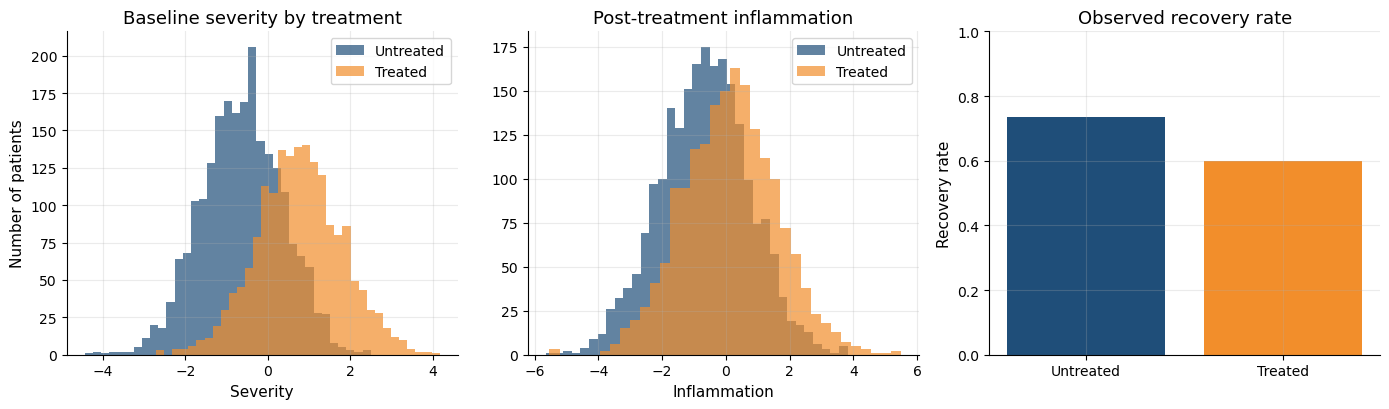

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Severity by treatment group
axes[0].hist(health.loc[health["Treatment"] == 0, "Severity"], bins=35, alpha=0.70,
             label="Untreated", color=COLORS["navy"])
axes[0].hist(health.loc[health["Treatment"] == 1, "Severity"], bins=35, alpha=0.70,
             label="Treated", color=COLORS["orange"])
axes[0].set_title("Baseline severity by treatment")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Number of patients")
axes[0].legend()
clean_axis(axes[0])

# Inflammation by treatment group
axes[1].hist(health.loc[health["Treatment"] == 0, "Inflammation"], bins=35, alpha=0.70,
             label="Untreated", color=COLORS["navy"])
axes[1].hist(health.loc[health["Treatment"] == 1, "Inflammation"], bins=35, alpha=0.70,
             label="Treated", color=COLORS["orange"])
axes[1].set_title("Post-treatment inflammation")
axes[1].set_xlabel("Inflammation")
axes[1].legend()
clean_axis(axes[1])

# Recovery rates by treatment group
rates = health.groupby("Treatment")["Recovery"].mean()
axes[2].bar(["Untreated", "Treated"], rates.values, color=[COLORS["navy"], COLORS["orange"]])
axes[2].set_title("Observed recovery rate")
axes[2].set_ylabel("Recovery rate")
axes[2].set_ylim(0, 1)
clean_axis(axes[2])

plt.tight_layout()
plt.show()

### Interpretation

The plots show the same issue visually. Treated patients tend to have higher baseline severity, different post-treatment inflammation, and lower observed recovery.

The key point is that the treated group starts from a worse baseline condition. Therefore,

$$P(Recovery=1 \mid Treatment=1) - P(Recovery=1 \mid Treatment=0)$$

is only an associational comparison. To estimate a causal effect, we need a graph-based adjustment strategy.

</br></br>

---
## 3. Directed Acyclic Graphs as causal assumption maps

A **Directed Acyclic Graph (DAG)** consists of:

- nodes, representing variables,
- directed edges, representing direct causal assumptions,
- no directed cycles, meaning a variable cannot cause itself through a directed path.

A graph is **acyclic** if there is no sequence such as $X_1 \rightarrow X_2 \rightarrow \cdots \rightarrow X_1$.

The DAG below summarizes our assumed data-generating process.

### Example: Assumed DAG for the healthcare case study

The DAG below summarizes the causal assumptions for the healthcare example. Each node is a variable, and each arrow represents an assumed direct causal influence.

The main causal question is whether `Treatment` improves `Recovery`. The graph shows why this question is not simple: pre-treatment variables such as `Age`, `Socioeconomic`, `Severity`, and `Biomarker` may influence treatment assignment and recovery.

The graph also includes:

$$Treatment \rightarrow Inflammation \rightarrow Recovery$$

where `Inflammation` is a post-treatment mediator, and

$$Severity \rightarrow SpecialistClinic \leftarrow Access$$

where `SpecialistClinic` is a collider or selection variable.

This DAG is not learned from the data. It is an assumption map that we will use to reason about confounding, mediation, collider bias, d-separation, adjustment, and causal discovery.

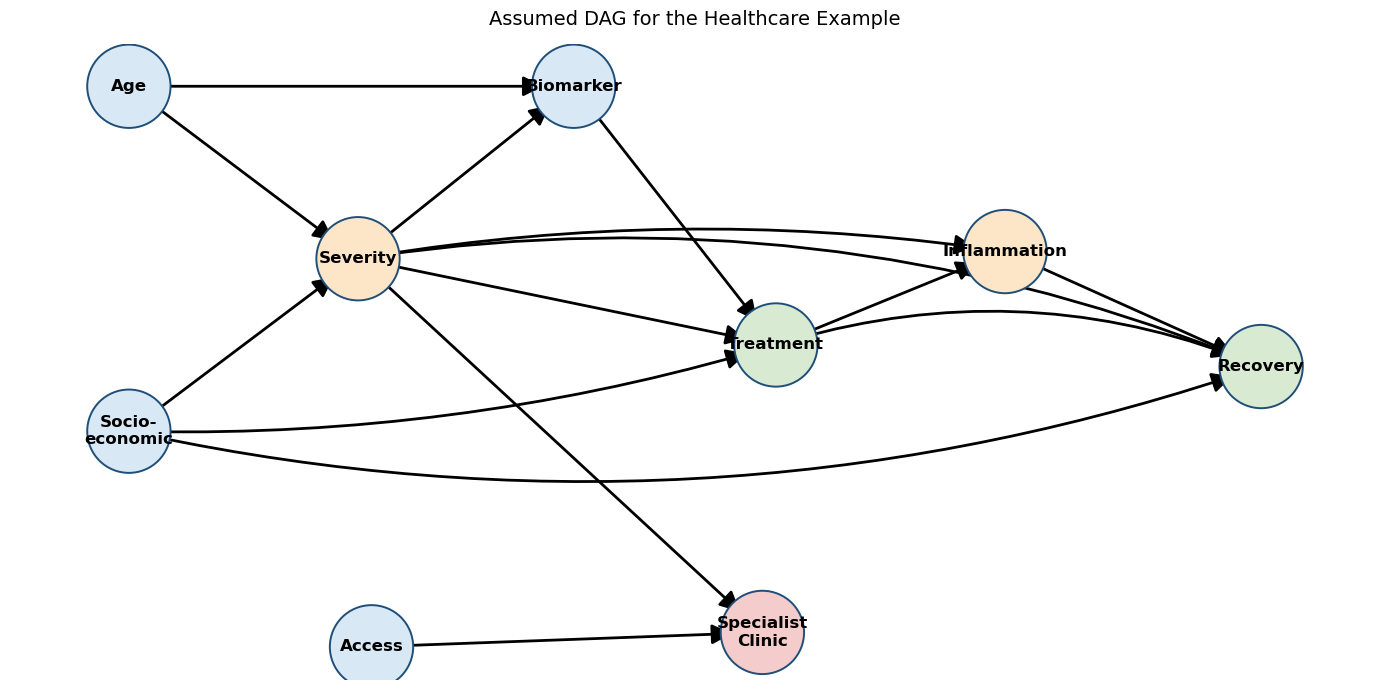

In [62]:
# ---------------------------------------------------------------------
# Assumed DAG for the healthcare example
# ---------------------------------------------------------------------

true_edges = [
    ("Age", "Severity"),
    ("Age", "Biomarker"),
    ("Socioeconomic", "Severity"),
    ("Socioeconomic", "Treatment"),
    ("Socioeconomic", "Recovery"),
    ("Severity", "Biomarker"),
    ("Severity", "Treatment"),
    ("Biomarker", "Treatment"),
    ("Severity", "Inflammation"),
    ("Treatment", "Inflammation"),
    ("Treatment", "Recovery"),
    ("Severity", "Recovery"),
    ("Inflammation", "Recovery"),
    ("Severity", "SpecialistClinic"),
    ("Access", "SpecialistClinic"),
]

# Layout designed to separate the treatment, mediator, and outcome nodes.
pos = {
    "Age": (-3.5, 1.8),
    "Socioeconomic": (-3.5, -0.6),
    "Severity": (-1.8, 0.6),
    "Biomarker": (-0.2, 1.8),
    "Treatment": (1.3, 0.0),
    "Inflammation": (3.0, 0.65),
    "Recovery": (4.9, -0.15),
    "Access": (-1.7, -2.1),
    "SpecialistClinic": (1.2, -2.0),
}

node_colors = {
    "Age": COLORS["light_blue"],
    "Socioeconomic": COLORS["light_blue"],
    "Severity": COLORS["light_orange"],
    "Biomarker": COLORS["light_blue"],
    "Treatment": COLORS["light_green"],
    "Inflammation": COLORS["light_orange"],
    "Recovery": COLORS["light_green"],
    "Access": COLORS["light_blue"],
    "SpecialistClinic": COLORS["light_red"],
}

# Shorter display labels for long node names
node_labels = {
    "Age": "Age",
    "Socioeconomic": "Socio-\neconomic",
    "Severity": "Severity",
    "Biomarker": "Biomarker",
    "Treatment": "Treatment",
    "Inflammation": "Inflammation",
    "Recovery": "Recovery",
    "Access": "Access",
    "SpecialistClinic": "Specialist\nClinic",
}

# Only curve the long or visually overlapping edges.
# Positive and negative values bend edges in opposite directions.
edge_rads = {
    ("Socioeconomic", "Treatment"): 0.08,
    ("Socioeconomic", "Recovery"): 0.14,
    ("Severity", "Inflammation"): -0.08,
    ("Severity", "Recovery"): -0.14,
    ("Treatment", "Recovery"): -0.18,
}

G_true = draw_dag(
    true_edges,
    pos=pos,
    title="Assumed DAG for the Healthcare Example",
    node_colors=node_colors,
    labels=node_labels,
    figsize=(14, 7),
    node_size=3600,
    font_size=12,
    arrowsize=30,
    edge_width=2.0,
    edge_rad=0.0,      # most edges remain straight
    edge_rads=edge_rads # only selected long edges are curved
);

### Reading the graph

The graph encodes several causal assumptions:

- `Severity` is a common cause of `Treatment`, `Inflammation`, `Recovery`, and `SpecialistClinic`.
- `Treatment` directly affects `Recovery` and indirectly affects `Recovery` through `Inflammation`.
- `SpecialistClinic` is a collider because it is caused by both `Severity` and `Access`.
- `Inflammation` is a mediator on the path `Treatment` $\rightarrow$ `Inflammation` $\rightarrow$ `Recovery`.

The graph is not automatically true. It is a structured statement of what we believe about the system.

**Note on node colors.**  
The colors are used only as visual teaching aids. 
- **Light blue** nodes indicate background or pre-treatment variables, such as `Age`, `Socioeconomic`, `Biomarker`, and `Access`. 
- **Light orange** nodes highlight variables with important causal roles, such as `Severity` as a confounder and `Inflammation` as a mediator. 
- **Light green** nodes indicate the main treatment-outcome pair, `Treatment` and `Recovery`. 
- **Light red** indicates a collider or selection variable, here `SpecialistClinic`.

The colors do not represent statistical significance, causal strength, or confidence in the edges.

</br></br>

---
## 4. Graph terminology

Let $G=(V,E)$ be a graph with nodes $V$ and edges $E$.

Important terms:

- **Node:** a variable, such as `Treatment` or `Recovery`.
- **Directed edge:** $X \rightarrow Y$, interpreted as a direct causal effect of $X$ on $Y$ under the assumed graph.
- **Path:** any sequence of connected nodes, regardless of arrow direction.
- **Directed path:** a path that follows arrow directions.
- **Parent:** $X$ is a parent of $Y$ if $X \rightarrow Y$.
- **Child:** $Y$ is a child of $X$ if $X \rightarrow Y$.
- **Ancestor:** $X$ is an ancestor of $Y$ if there is a directed path from $X$ to $Y$.
- **Descendant:** $Y$ is a descendant of $X$ if there is a directed path from $X$ to $Y$.

--- 
### Example: Inspecting graph relationships with Python

Once a DAG is defined, we can use Python to inspect each variable’s role in the graph.

The function below returns:

- **parents**: variables with arrows into the selected node,
- **children**: variables that receive arrows from the selected node,
- **ancestors**: variables that can reach the node through directed paths,
- **descendants**: variables reachable from the node through directed paths.

We inspect `Treatment` and `Recovery` because they define the main causal question in this chapter.

In [63]:
def graph_relations(G, node):
    return {
        "parents": sorted(list(G.predecessors(node))),
        "children": sorted(list(G.successors(node))),
        "ancestors": sorted(list(nx.ancestors(G, node))),
        "descendants": sorted(list(nx.descendants(G, node))),
    }

graph_relations(G_true, "Treatment")

{'parents': ['Biomarker', 'Severity', 'Socioeconomic'],
 'children': ['Inflammation', 'Recovery'],
 'ancestors': ['Age', 'Biomarker', 'Severity', 'Socioeconomic'],
 'descendants': ['Inflammation', 'Recovery']}

In [64]:
graph_relations(G_true, "Recovery")

{'parents': ['Inflammation', 'Severity', 'Socioeconomic', 'Treatment'],
 'children': [],
 'ancestors': ['Age',
  'Biomarker',
  'Inflammation',
  'Severity',
  'Socioeconomic',
  'Treatment'],
 'descendants': []}

</br></br>

---
## 5. Three Core DAG Structures

Most graphical reasoning in causal inference can be understood through three structures:

1. **Fork/confounder:** $X \leftarrow Z \rightarrow Y$
2. **Chain/mediator:** $X \rightarrow M \rightarrow Y$
3. **Collider:** $X \rightarrow C \leftarrow Y$

These structures determine whether a path is blocked or active under conditioning.

---
### 5.1 Fork Structure: Confounding

A fork occurs when a common cause affects two variables:

$$Treatment \leftarrow Severity \rightarrow Recovery$$

Here, `Severity` is a confounder because it affects both treatment assignment and recovery.

If we ignore `Severity`, the association between `Treatment` and `Recovery` can be biased. Conditioning on the confounder can block the backdoor path.

### Example: Severity as a confounder in treatment evaluation

We now return to the healthcare case study introduced earlier in the chapter. The goal is to understand whether `Treatment` improves `Recovery`.

A simple comparison between treated and untreated patients may seem reasonable at first. However, in observational hospital data, treatment is usually not assigned randomly. Patients with higher baseline severity may be more likely to receive treatment. At the same time, severity can also affect the probability of recovery.

This creates the following causal structure:

$$Treatment \leftarrow Severity \rightarrow Recovery$$

This is called a **fork structure** because one variable, `Severity`, points toward two other variables. It is also a **confounding structure** because `Severity` creates a non-causal path between `Treatment` and `Recovery`.

In this example, we compare two quantities:

1. The **naive observed difference**, which compares recovery rates between treated and untreated patients.
2. An **adjusted estimate**, which compares treated and untreated patients after accounting for relevant pre-treatment variables.

The purpose is to show why the raw comparison can be misleading and how causal graphs help us decide what should be adjusted for.

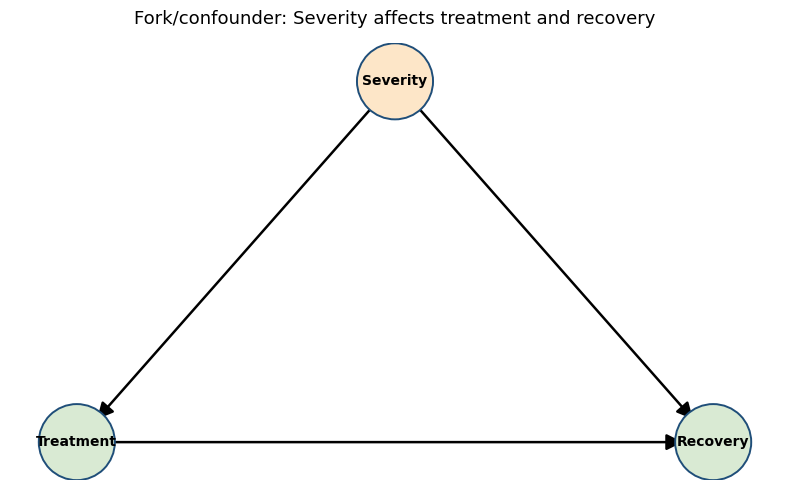

In [65]:
fork_edges = [("Severity", "Treatment"), ("Severity", "Recovery"), ("Treatment", "Recovery")]
fork_pos = {"Severity": (0, 1), "Treatment": (-1, 0), "Recovery": (1, 0)}
fork_colors = {"Severity": COLORS["light_orange"], "Treatment": COLORS["light_green"], "Recovery": COLORS["light_green"]}
G_fork = draw_dag(
    fork_edges,
    pos=fork_pos,
    title="Fork/confounder: Severity affects treatment and recovery",
    node_colors=fork_colors
);

Naive observed difference: -0.136
Adjusted estimate using pre-treatment variables: 0.167


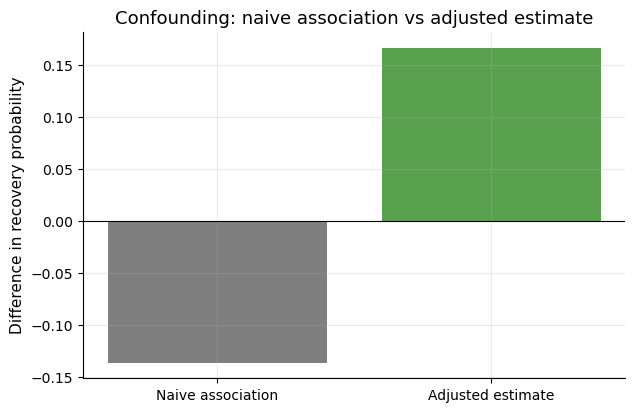

In [66]:
# Naive association
naive_treated = health.loc[health["Treatment"] == 1, "Recovery"].mean()
naive_untreated = health.loc[health["Treatment"] == 0, "Recovery"].mean()
naive_diff = naive_treated - naive_untreated

# Adjusted estimate using a simple outcome model with pre-treatment confounders
X_adj = health[["Treatment", "Severity", "Biomarker", "Age", "Socioeconomic"]]
y = health["Recovery"]
logit = LogisticRegression(max_iter=1000)
logit.fit(X_adj, y)

health_do1 = health.copy()
health_do0 = health.copy()
health_do1["Treatment"] = 1
health_do0["Treatment"] = 0

adj_do1 = logit.predict_proba(health_do1[["Treatment", "Severity", "Biomarker", "Age", "Socioeconomic"]])[:, 1].mean()
adj_do0 = logit.predict_proba(health_do0[["Treatment", "Severity", "Biomarker", "Age", "Socioeconomic"]])[:, 1].mean()
adj_diff = adj_do1 - adj_do0

print(f"Naive observed difference: {naive_diff:.3f}")
print(f"Adjusted estimate using pre-treatment variables: {adj_diff:.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(["Naive association", "Adjusted estimate"], [naive_diff, adj_diff], color=[COLORS["gray"], COLORS["green"]])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Confounding: naive association vs adjusted estimate")
ax.set_ylabel("Difference in recovery probability")
clean_axis(ax)
plt.show()

### Interpretation

`Severity` is a common cause of both `Treatment` and `Recovery`:

$$Treatment \leftarrow Severity \rightarrow Recovery$$

This creates a non-causal path between treatment and recovery. In the raw data, treated patients appear to have lower recovery, but this is misleading because treated patients are more severe at baseline.

After adjusting for relevant pre-treatment variables, the estimate becomes positive. The example shows the main confounding lesson:

> A treatment can look harmful in observational data when the treated group starts from a worse baseline condition.

Causal graphs help us identify this problem before interpreting the raw comparison as a causal effect.

---
### 5.2 Chain Structure: Mediation

A chain occurs when one variable transmits part of the effect of another variable:

$$Treatment \rightarrow Inflammation \rightarrow Recovery$$

Here, `Inflammation` is a mediator. If the scientific question is the **total effect** of treatment on recovery, adjusting for the mediator can remove part of the effect we want to estimate. Adjusting means comparing groups as if they were similar in some variable. This can help when the variable is a confounder, but it can hurt when the variable is a mediator or collider.

This is an important distinction:

- Adjust for pre-treatment confounders when estimating a treatment effect.
- Do not adjust for post-treatment mediators when estimating the total effect.
- Adjusting for mediators may be useful for mediation analysis, but it changes the estimand.

### Example: Inflammation as a mediator of treatment effect

We continue with the same healthcare case study, but now we focus on a different type of causal structure.

Suppose the treatment affects recovery partly by changing the patient’s inflammation level after treatment. In this case, `Inflammation` lies on a causal path from `Treatment` to `Recovery`:

$$Treatment \rightarrow Inflammation \rightarrow Recovery$$

In the graph, there is also a direct path from treatment to recovery:

$$Treatment \rightarrow Recovery$$

This means that treatment may improve recovery in two ways:

1. **Indirectly**, by changing inflammation.
2. **Directly**, through mechanisms not represented by inflammation.

A variable like `Inflammation`, which transmits part of the effect of a treatment to the outcome, is called a **mediator**.

In this example, we compare two adjusted estimates:

1. An estimate that adjusts only for appropriate **pre-treatment variables**.
2. An estimate that also adjusts for the **mediator** `Inflammation`.

The purpose is to show that including a mediator in the adjustment set changes the question we are answering.

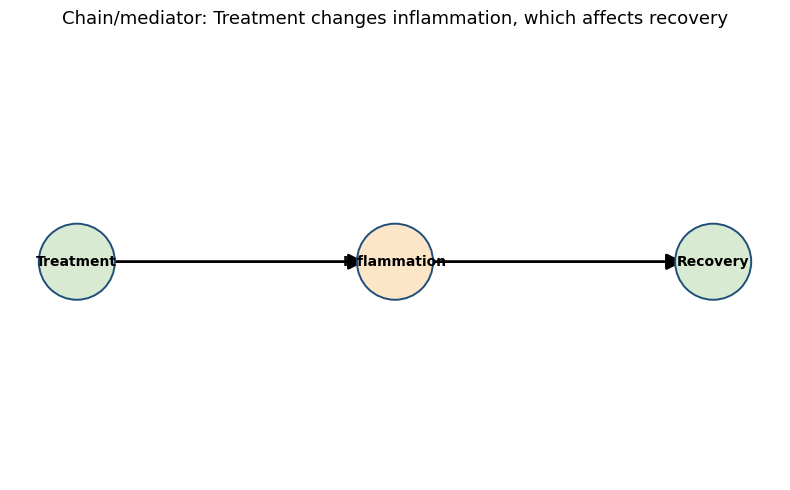

In [67]:
chain_edges = [("Treatment", "Inflammation"), ("Inflammation", "Recovery"), ("Treatment", "Recovery")]
chain_pos = {"Treatment": (-1.2, 0), "Inflammation": (0, 0), "Recovery": (1.2, 0)}
chain_colors = {"Treatment": COLORS["light_green"], "Inflammation": COLORS["light_orange"], "Recovery": COLORS["light_green"]}
G_chain = draw_dag(
    chain_edges,
    pos=chain_pos,
    title="Chain/mediator: Treatment changes inflammation, which affects recovery",
    node_colors=chain_colors
);

Adjusted estimate without mediator: 0.167
Adjusted estimate with mediator included: 0.100


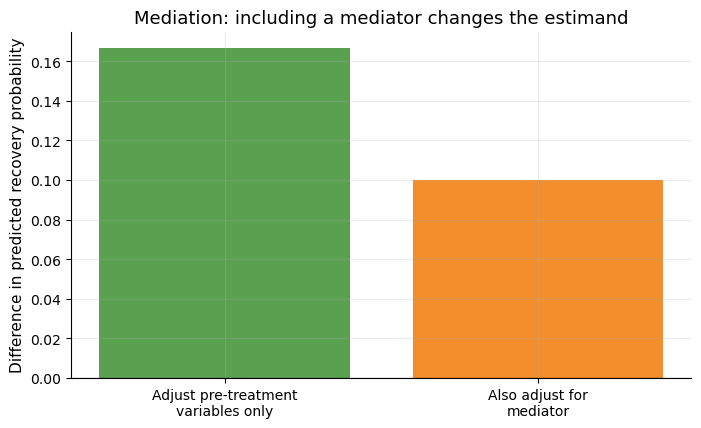

In [68]:
# Compare outcome models with and without the mediator
pre_treatment_vars = ["Treatment", "Severity", "Biomarker", "Age", "Socioeconomic"]
mediator_model_vars = pre_treatment_vars + ["Inflammation"]

model_total = LogisticRegression(max_iter=1000).fit(health[pre_treatment_vars], health["Recovery"])
model_direct = LogisticRegression(max_iter=1000).fit(health[mediator_model_vars], health["Recovery"])

do1 = health.copy(); do1["Treatment"] = 1
do0 = health.copy(); do0["Treatment"] = 0

# Total-effect style prediction: do not hold mediator fixed
est_total = (
    model_total.predict_proba(do1[pre_treatment_vars])[:, 1].mean()
    - model_total.predict_proba(do0[pre_treatment_vars])[:, 1].mean()
)

# Direct-effect style association: holds observed mediator fixed in the model
est_with_mediator = (
    model_direct.predict_proba(do1[mediator_model_vars])[:, 1].mean()
    - model_direct.predict_proba(do0[mediator_model_vars])[:, 1].mean()
)

print(f"Adjusted estimate without mediator: {est_total:.3f}")
print(f"Adjusted estimate with mediator included: {est_with_mediator:.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(
    ["Adjust pre-treatment\nvariables only", "Also adjust for\nmediator"],
    [est_total, est_with_mediator],
    color=[COLORS["green"], COLORS["orange"]]
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Mediation: including a mediator changes the estimand")
ax.set_ylabel("Difference in predicted recovery probability")
clean_axis(ax)
plt.show()

### Interpretation

`Inflammation` is measured after treatment and lies on the pathway:

$$Treatment \rightarrow Inflammation \rightarrow Recovery$$

The estimate that adjusts only for pre-treatment variables is about:

$$0.167$$

This is closer to the total effect because it keeps both the direct path and the indirect path through inflammation.

When `Inflammation` is also included, the estimate becomes smaller:

$$0.100$$

This happens because adjusting for a mediator removes part of the pathway through which treatment affects recovery.

The key lesson is:

> **If the goal is the total effect of treatment, we usually should not adjust for post-treatment mediators.**

Mediators may be useful for mediation analysis, but then the causal question changes.

---
### 5.3 Collider Structure: Selection Bias

A collider occurs when two variables cause a common effect:

$$Severity \rightarrow SpecialistClinic \leftarrow Access$$

Before we condition on `SpecialistClinic`, this path does **not transmit association** between `Severity` and `Access`. In this simulated example, `Severity` and `Access` were generated independently, so they are approximately unrelated in the full dataset.

However, if we restrict the analysis to patients with `SpecialistClinic = 1`, an association can appear. This happens because entry into the specialist clinic depends on both severity and access. Among patients who enter the clinic, high severity can compensate for lower access, and high access can compensate for lower severity.

This is a selection effect. By analyzing only selected patients, we create a relationship between two variables that were originally independent.

The key rule is:

> **Conditioning on a collider can turn a previously blocked path into an active path.**

Here, “blocked” means that the path does not transmit statistical association. “Active” means that the path can transmit association after conditioning.

In simpler terms:

> **If two variables both affect selection into the dataset, analyzing only the selected cases can create a misleading association between them.**


### Example: Specialist clinic admission as a collider

We continue with the healthcare case study, but now we examine a different source of bias: **selection bias**.

Suppose that admission to a specialist clinic depends on two factors:

1. `Severity`: patients with more severe illness are more likely to be admitted.
2. `Access`: patients with better access to healthcare resources are also more likely to be admitted.

This creates the following structure:

$$Severity \rightarrow SpecialistClinic \leftarrow Access$$

This is called a **collider structure** because two arrows point into the same variable, `SpecialistClinic`.

In the full population, `Severity` and `Access` may be unrelated. However, if we restrict the analysis only to patients admitted to the specialist clinic, we are conditioning on the collider. This can create an artificial association between `Severity` and `Access`, even if no such relationship exists in the full population.

The purpose of this example is to show why datasets created through selection processes can be misleading. Hospital records and specialist clinic data often include only selected cases. If selection depends on multiple variables, conditioning on the selected sample can distort the relationships among those variables.

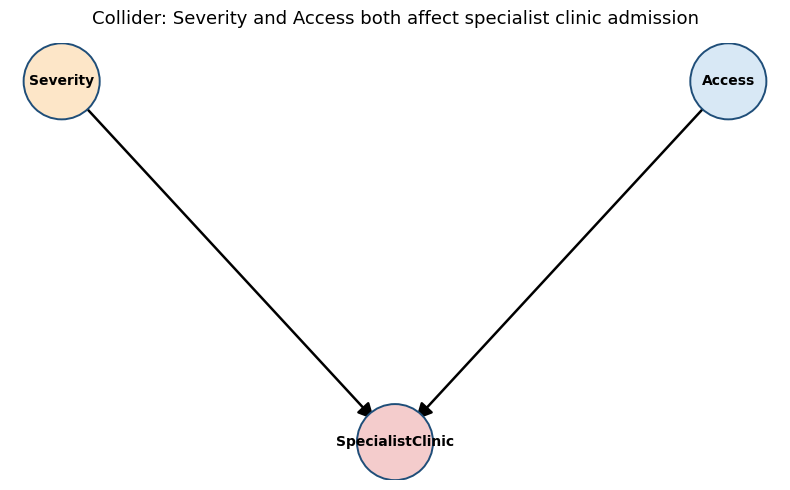

In [69]:
collider_edges = [("Severity", "SpecialistClinic"), ("Access", "SpecialistClinic")]
collider_pos = {"Severity": (-1, 0.7), "Access": (1, 0.7), "SpecialistClinic": (0, -0.4)}
collider_colors = {"Severity": COLORS["light_orange"], "Access": COLORS["light_blue"], "SpecialistClinic": COLORS["light_red"]}
G_collider = draw_dag(
    collider_edges,
    pos=collider_pos,
    title="Collider: Severity and Access both affect specialist clinic admission",
    node_colors=collider_colors
);

Correlation between Severity and Access in full data: -0.009
Correlation between Severity and Access among SpecialistClinic=1: -0.214


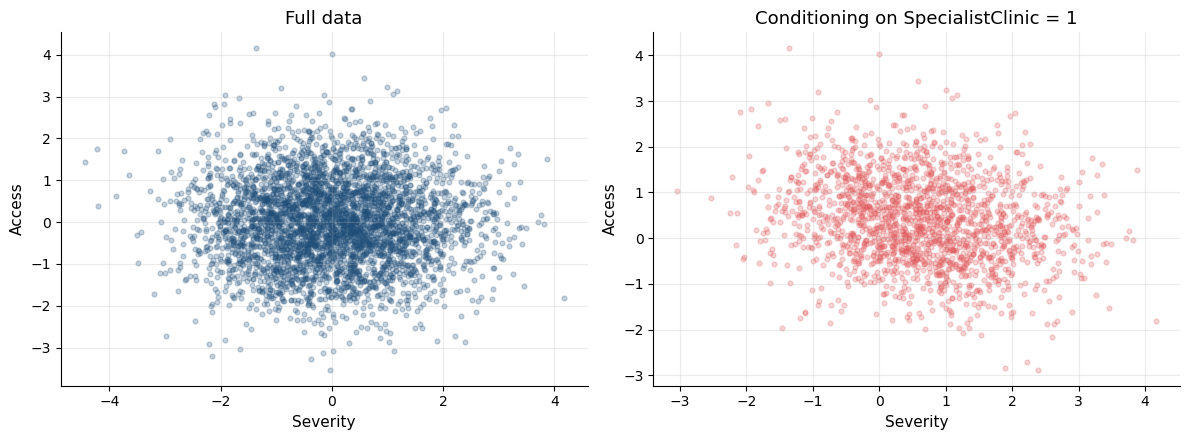

In [70]:
# Marginal correlation between Severity and Access
corr_all = health[["Severity", "Access"]].corr().iloc[0, 1]

# Correlation after conditioning on the collider SpecialistClinic = 1
clinic = health[health["SpecialistClinic"] == 1]
corr_clinic = clinic[["Severity", "Access"]].corr().iloc[0, 1]

print(f"Correlation between Severity and Access in full data: {corr_all:.3f}")
print(f"Correlation between Severity and Access among SpecialistClinic=1: {corr_clinic:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(health["Severity"], health["Access"], alpha=0.25, color=COLORS["navy"], s=12)
axes[0].set_title("Full data")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Access")
clean_axis(axes[0])

axes[1].scatter(clinic["Severity"], clinic["Access"], alpha=0.25, color=COLORS["red"], s=12)
axes[1].set_title("Conditioning on SpecialistClinic = 1")
axes[1].set_xlabel("Severity")
axes[1].set_ylabel("Access")
clean_axis(axes[1])

plt.tight_layout()
plt.show()

### Interpretation

`SpecialistClinic` is a collider because both `Severity` and `Access` affect admission:

$$Severity \rightarrow SpecialistClinic \leftarrow Access$$

In the full dataset, `Severity` and `Access` are approximately unrelated:

$$Corr(Severity, Access) \approx 0$$

After restricting the data to patients admitted to the specialist clinic, the correlation becomes negative:

$$Corr(Severity, Access \mid SpecialistClinic=1) = -0.214$$

This association is not a causal relationship. It appears because we selected only patients who entered the clinic. Among admitted patients, high severity can compensate for lower access, and high access can compensate for lower severity.

This is an example of **Berkson’s paradox**: conditioning on a common effect can create a misleading association between its causes.

The key lesson is:

> **Unlike confounders, colliders should generally not be adjusted for. Conditioning on a collider can create selection bias.**

</br>

---
## 6. Conditioning: When Does It Help or Hurt?

In causal analysis, we often **condition on variables**. This means we compare units that are similar with respect to those variables.

For example, we may compare treated and untreated patients with similar baseline severity.

But conditioning is not always helpful. Its effect depends on the causal role of the variable.

Conditioning can:

1. **reduce bias**, when we condition on a confounder;
2. **change the causal question**, when we condition on a mediator;
3. **create bias**, when we condition on a collider.

This is why causal graphs are useful. They help us decide which variables should, or should not, be included in an adjustment set.

The graphical rule behind this idea is called **d-separation**. For a visual and interactive explanation of d-separation, see Dagitty’s tutorial [*d-Separation Without Tears*](https://dagitty.net/learn/dsep/index.html).


For this chapter, we use the following practical version:

| Structure | Example | What conditioning does |
|---|---|---|
| **Fork / confounder** | $Treatment \leftarrow Severity \rightarrow Recovery$ | Conditioning on `Severity` helps block a non-causal path. |
| **Chain / mediator** | $Treatment \rightarrow Inflammation \rightarrow Recovery$ | Conditioning on `Inflammation` blocks part of the treatment effect. |
| **Collider** | $Severity \rightarrow SpecialistClinic \leftarrow Access$ | Conditioning on `SpecialistClinic` can create a misleading association. |

The practical message is:

> **Conditioning is a causal decision, not only a statistical decision.**

Before adding a variable to a model, ask:

> *What role does this variable play in the causal graph?*

---
### Example: Conditioning Changes the Association We Observe

The code below shows how different conditioning choices change the observed association between variables.

We compare four cases from the healthcare example:

1. `Treatment` and `Recovery` with no adjustment.
2. `Treatment` and `Recovery` after adjusting for **pre-treatment** variables.
3. `Treatment` and `Recovery` after also adjusting for the **post-treatment** mediator `Inflammation`.
4. `Severity` and `Access` before and after conditioning on the collider `SpecialistClinic`.

The goal is not to prove causality from correlations. The goal is to show that the graph-based warnings from earlier sections are also visible in the simulated data.

In [71]:
# ---------------------------------------------------------------------
# Conditioning diagnostics using simple partial correlations
# ---------------------------------------------------------------------

def residualize(y, X):
    """
    Return residuals from a linear regression of y on X.
    """
    y = np.asarray(y).reshape(-1)
    X = np.asarray(X)

    if X.ndim == 1:
        X = X.reshape(-1, 1)

    model = LinearRegression().fit(X, y)
    return y - model.predict(X)


def partial_corr(df, x, y, controls=None):
    """
    Compute correlation between x and y after linearly adjusting
    for the variables in controls.
    """
    controls = controls or []

    if len(controls) == 0:
        return df[[x, y]].corr().iloc[0, 1]

    rx = residualize(df[x], df[controls])
    ry = residualize(df[y], df[controls])

    return np.corrcoef(rx, ry)[0, 1]


conditioning_examples = [
    {
        "Question": "Raw treatment-recovery association",
        "X": "Treatment",
        "Y": "Recovery",
        "Conditioning variables": "None",
        "Value": partial_corr(health, "Treatment", "Recovery"),
        "Causal lesson": "Naive association may be confounded",
    },
    {
        "Question": "After adjusting for pre-treatment variables",
        "X": "Treatment",
        "Y": "Recovery",
        "Conditioning variables": "Severity, Biomarker, Age, Socioeconomic",
        "Value": partial_corr(
            health,
            "Treatment",
            "Recovery",
            ["Severity", "Biomarker", "Age", "Socioeconomic"],
        ),
        "Causal lesson": "Confounder adjustment changes the comparison",
    },
    {
        "Question": "After also adjusting for mediator",
        "X": "Treatment",
        "Y": "Recovery",
        "Conditioning variables": "Severity, Biomarker, Age, Socioeconomic, Inflammation",
        "Value": partial_corr(
            health,
            "Treatment",
            "Recovery",
            ["Severity", "Biomarker", "Age", "Socioeconomic", "Inflammation"],
        ),
        "Causal lesson": "Mediator adjustment changes the estimand",
    },
    {
        "Question": "Raw severity-access association",
        "X": "Severity",
        "Y": "Access",
        "Conditioning variables": "None",
        "Value": partial_corr(health, "Severity", "Access"),
        "Causal lesson": "Variables are nearly unrelated in full data",
    },
    {
        "Question": "After conditioning on collider",
        "X": "Severity",
        "Y": "Access",
        "Conditioning variables": "SpecialistClinic",
        "Value": partial_corr(
            health,
            "Severity",
            "Access",
            ["SpecialistClinic"],
        ),
        "Causal lesson": "Collider conditioning creates association",
    },
]

conditioning_table = pd.DataFrame(conditioning_examples)
conditioning_table["Value"] = conditioning_table["Value"].round(3)

display(conditioning_table)

,Question,X,Y,Conditioning variables,Value,Causal lesson
0,Raw treatment-recovery association,Treatment,Recovery,None,-0.144,Naive association may be confounded
1,After adjusting for pre-treatment variables,Treatment,Recovery,"Severity, Biomarker, Age, Socioeconomic",0.175,Confounder adjustment changes the comparison
2,After also adjusting for mediator,Treatment,Recovery,"Severity, Biomarker, Age, Socioeconomic, Infla...",0.097,Mediator adjustment changes the estimand
3,Raw severity-access association,Severity,Access,None,-0.009,Variables are nearly unrelated in full data
4,After conditioning on collider,Severity,Access,SpecialistClinic,-0.204,Collider conditioning creates association


### Interpretation

The table shows that conditioning choices can strongly change the associations we observe.

For `Treatment` and `Recovery`, the raw association is negative. This is because treated patients are more severe at baseline. After adjusting for pre-treatment variables, the association becomes positive.

When we also adjust for `Inflammation`, the association becomes smaller. This is expected because `Inflammation` is a mediator:

$$Treatment \rightarrow Inflammation \rightarrow Recovery$$

Adjusting for it removes part of the treatment pathway and changes the causal question.

For `Severity` and `Access`, the raw association is close to zero. But after conditioning on `SpecialistClinic`, an association appears. This happens because `SpecialistClinic` is a collider:

$$Severity \rightarrow SpecialistClinic \leftarrow Access$$

The key lesson is:

> Conditioning can reduce bias, change the estimand, or create bias. The effect depends on the causal graph.

Therefore, adjustment should be guided by causal reasoning, not by automatic variable selection.

</br></br>

---
## 7. Backdoor Adjustment for the Same Example

Suppose we want to estimate the total effect of `Treatment` on `Recovery`.

The causal question is:

$$P(Recovery=1 \mid do(Treatment=1)) - P(Recovery=1 \mid do(Treatment=0))$$

This asks what would happen if we assigned treatment, or no treatment, to the same target population.

This is different from the observed comparison:

$$P(Recovery=1 \mid Treatment=1) - P(Recovery=1 \mid Treatment=0)$$

The observed comparison may be biased because treatment was not randomly assigned. In this hospital example, sicker patients are more likely to receive treatment.

</br>

A **backdoor path** is any path that connects the treatment and the outcome but starts with an arrow pointing **into** the treatment variable.

Because the first arrow points into the treatment, the path does not represent the causal effect of treatment on the outcome. It represents a **non-causal** route that can create bias.

One important backdoor path is:

$$Treatment \leftarrow Severity \rightarrow Recovery$$

This is not the causal effect of treatment. It is a non-causal path connecting treatment and recovery through baseline severity.

Another related path is:

$$Treatment \leftarrow Biomarker \leftarrow Severity \rightarrow Recovery$$

These paths matter because they can make treatment and recovery look related due to pre-treatment patient differences.

The goal of **backdoor adjustment** is to block these non-causal paths by adjusting for appropriate pre-treatment variables.

</br>

To write the adjustment compactly, we define an **adjustment set** $Z$.

Here, $Z$ is not one variable. It is the set of variables we adjust for when comparing treated and untreated patients.

For the total effect of `Treatment` on `Recovery`, we use:

$$Z = \{Age, Socioeconomic, Severity, Biomarker\}$$

These variables are measured before treatment. Adjusting for $Z$ means comparing treated and untreated patients with similar:

- age,
- socioeconomic status,
- baseline severity,
- and biomarker values.

The backdoor-adjusted effect can be written as:

$$
\sum_z P(Recovery=1 \mid Treatment=1, Z=z)P(Z=z)
-
\sum_z P(Recovery=1 \mid Treatment=0, Z=z)P(Z=z)
$$

In words, this means:

> Compare treated and untreated patients within similar values of $Z$, and then average those comparisons over the full population.

After adjustment, the comparison is closer to the causal question. It no longer relies only on the raw difference between all treated and untreated patients.

We should not adjust for:

- `Inflammation`, because it is a post-treatment mediator;
- `SpecialistClinic`, because it is a collider or selection variable.

The practical rule is:

> **Adjust for relevant pre-treatment common causes, but avoid post-treatment mediators and colliders.**


---

### Example: Visualizing and estimating backdoor adjustment

The next code cell connects the graph idea to a numerical estimate.

We do three things:

1. **Show the adjustment strategy on the DAG**
   - orange nodes: variables we adjust for,
   - green nodes: treatment and outcome,
   - red nodes: variables we avoid for the total effect.

2. **Compute the naive observed comparison**

$$P(Recovery=1 \mid Treatment=1) - P(Recovery=1 \mid Treatment=0)$$

3. **Compute the backdoor-adjusted effect**

We fit an outcome model using `Treatment` and the adjustment set $Z$, then predict recovery under two hypothetical interventions:

$$do(Treatment=1)$$

and

$$do(Treatment=0)$$

The goal is to show how the estimate changes when we compare patients more fairly using the adjustment set.

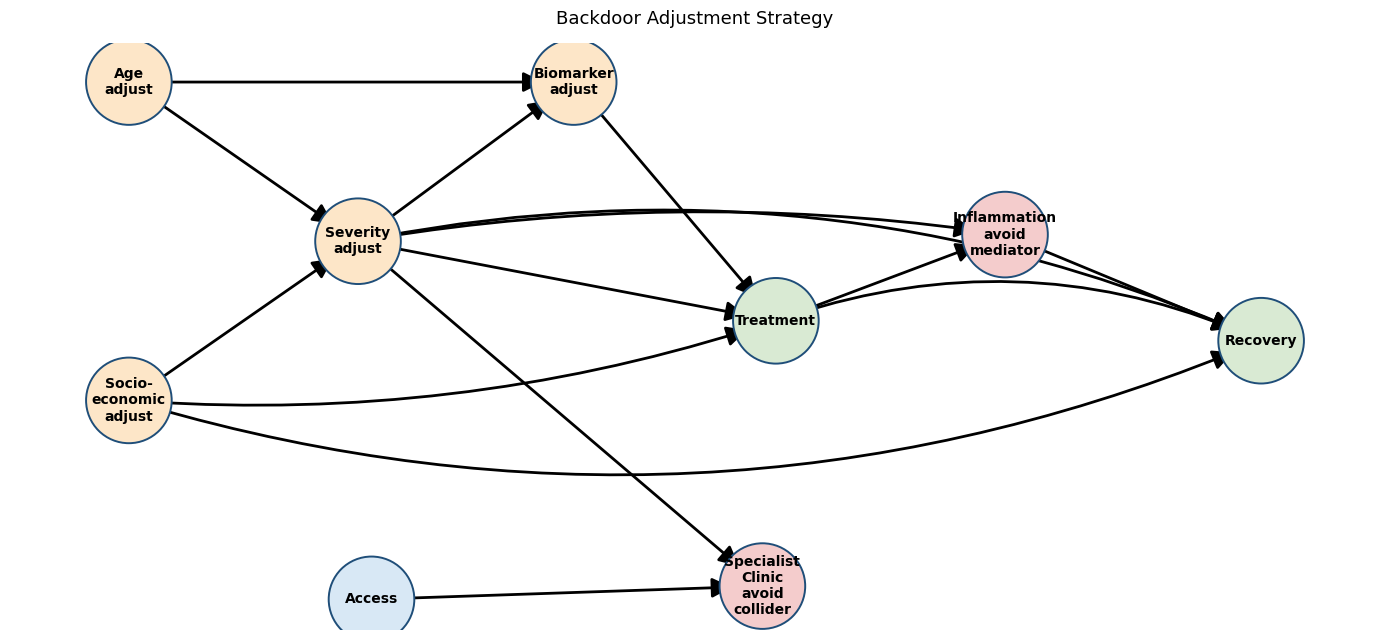

In [72]:
# ---------------------------------------------------------------------
# Backdoor adjustment: DAG + numerical example
# ---------------------------------------------------------------------

# Adjustment variables for the total effect
adjustment_set = ["Age", "Socioeconomic", "Severity", "Biomarker"]

# ---------------------------------------------------------------------
# 1. Visualize the adjustment strategy on the DAG
# ---------------------------------------------------------------------

adjustment_colors = {node: COLORS["light_blue"] for node in G_true.nodes()}

# Variables to adjust for
for node in adjustment_set:
    adjustment_colors[node] = COLORS["light_orange"]

# Treatment and outcome
adjustment_colors["Treatment"] = COLORS["light_green"]
adjustment_colors["Recovery"] = COLORS["light_green"]

# Variables to avoid for the total effect
adjustment_colors["Inflammation"] = COLORS["light_red"]
adjustment_colors["SpecialistClinic"] = COLORS["light_red"]

adjustment_labels = {
    "Age": "Age\nadjust",
    "Socioeconomic": "Socio-\neconomic\nadjust",
    "Severity": "Severity\nadjust",
    "Biomarker": "Biomarker\nadjust",
    "Treatment": "Treatment",
    "Inflammation": "Inflammation\navoid\nmediator",
    "Recovery": "Recovery",
    "Access": "Access",
    "SpecialistClinic": "Specialist\nClinic\navoid\ncollider",
}

adjustment_edge_rads = {
    ("Socioeconomic", "Treatment"): 0.10,
    ("Socioeconomic", "Recovery"): 0.18,
    ("Severity", "Inflammation"): -0.08,
    ("Severity", "Recovery"): -0.16,
    ("Treatment", "Recovery"): -0.20,
}

G_backdoor = draw_dag(
    true_edges,
    pos=pos,
    title="Backdoor Adjustment Strategy",
    node_colors=adjustment_colors,
    labels=adjustment_labels,
    figsize=(14, 6.5),
    node_size=3800,
    font_size=10,
    arrows=True,
    arrowsize=30,
    edge_width=2.0,
    edge_rad=0.0,
    edge_rads=adjustment_edge_rads,
)

### Interpretation of the DAG

The DAG shows which variables we adjust for and which variables we avoid.

The **orange nodes** are the adjustment set:

$$Z = \{Age, Socioeconomic, Severity, Biomarker\}$$

These variables are measured before treatment. They help block non-causal backdoor paths into `Treatment`, such as:

$$Treatment \leftarrow Severity \rightarrow Recovery$$

The **green nodes** are the main treatment-outcome pair:

$$Treatment \rightarrow Recovery$$

The **red nodes** should generally be avoided when estimating the total effect:

- `Inflammation` is a post-treatment mediator;
- `SpecialistClinic` is a collider or selection variable.

The main idea is:

> **Adjust for relevant pre-treatment variables, but avoid variables that lie after treatment or create selection bias.**

In [73]:
# ---------------------------------------------------------------------
# 2. Naive observed comparison
# ---------------------------------------------------------------------

naive_treated = health.loc[health["Treatment"] == 1, "Recovery"].mean()
naive_untreated = health.loc[health["Treatment"] == 0, "Recovery"].mean()
naive_difference = naive_treated - naive_untreated

# ---------------------------------------------------------------------
# 3. Backdoor adjustment using model-based standardization
# ---------------------------------------------------------------------

X_backdoor = health[["Treatment"] + adjustment_set]
y_backdoor = health["Recovery"]

backdoor_model = LogisticRegression(max_iter=1000)
backdoor_model.fit(X_backdoor, y_backdoor)

# Create two hypothetical intervention datasets:
# one where everyone is treated, and one where no one is treated.
do_treat = health.copy()
do_control = health.copy()

do_treat["Treatment"] = 1
do_control["Treatment"] = 0

p_do_treat = backdoor_model.predict_proba(
    do_treat[["Treatment"] + adjustment_set]
)[:, 1].mean()

p_do_control = backdoor_model.predict_proba(
    do_control[["Treatment"] + adjustment_set]
)[:, 1].mean()

backdoor_effect = p_do_treat - p_do_control

# ---------------------------------------------------------------------
# 4. Summarize results
# ---------------------------------------------------------------------

backdoor_results = pd.DataFrame({
    "Quantity": [
        "Observed recovery rate among treated patients",
        "Observed recovery rate among untreated patients",
        "Naive observed difference",
        "Estimated recovery if everyone were treated",
        "Estimated recovery if no one were treated",
        "Backdoor-adjusted effect",
    ],
    "Value": [
        naive_treated,
        naive_untreated,
        naive_difference,
        p_do_treat,
        p_do_control,
        backdoor_effect,
    ],
})

display(backdoor_results.round(3))

,Quantity,Value
0,Observed recovery rate among treated patients,0.599
1,Observed recovery rate among untreated patients,0.735
2,Naive observed difference,-0.136
3,Estimated recovery if everyone were treated,0.750
4,Estimated recovery if no one were treated,0.584
5,Backdoor-adjusted effect,0.167


### Interpretation of the numerical estimates

The first two rows show the observed recovery rates:

- treated patients: **0.599**
- untreated patients: **0.735**

So the naive observed difference is:

$$0.599 - 0.735 = -0.136$$

At first glance, this suggests that treated patients recover less often.

But this is not a fair causal comparison. Treated patients are more severe at baseline, so the two groups are not comparable.

The model-based adjustment estimates two hypothetical quantities:

- estimated recovery if everyone were treated: **0.750**
- estimated recovery if no one were treated: **0.584**

So the **backdoor-adjusted effect** is:

$$0.750 - 0.584 = 0.167$$

After adjustment, the estimated treatment effect is positive.

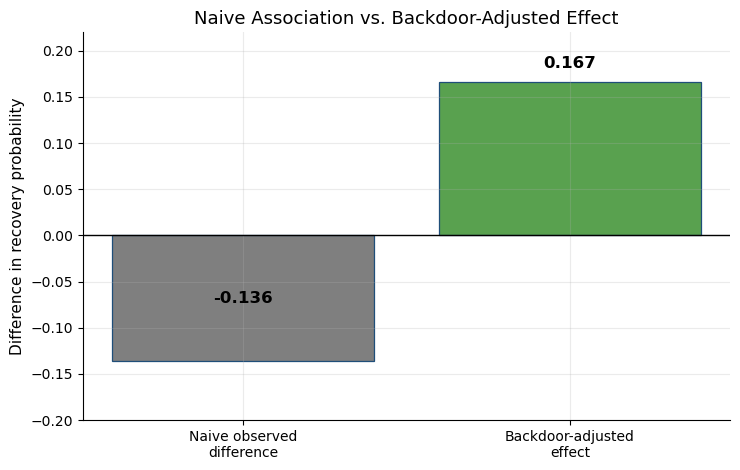

In [74]:
# ---------------------------------------------------------------------
# 5. Visualization: naive association vs. backdoor-adjusted effect
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.5, 4.8))

effect_labels = [
    "Naive observed\ndifference",
    "Backdoor-adjusted\neffect"
]

effect_values = [
    naive_difference,
    backdoor_effect
]

effect_colors = [
    COLORS["gray"],
    COLORS["green"]
]

bars = ax.bar(
    effect_labels,
    effect_values,
    color=effect_colors,
    edgecolor=COLORS["navy"],
    linewidth=0.9
)

ax.axhline(0, color="black", linewidth=1.0)
ax.set_title("Naive Association vs. Backdoor-Adjusted Effect")
ax.set_ylabel("Difference in recovery probability")
ax.set_ylim(-0.20, 0.22)

for bar, value in zip(bars, effect_values):
    x = bar.get_x() + bar.get_width() / 2

    if value >= 0:
        y = value + 0.012
        va = "bottom"
    else:
        y = value / 2
        va = "center"

    ax.text(
        x,
        y,
        f"{value:.3f}",
        ha="center",
        va=va,
        fontsize=12,
        fontweight="bold"
    )

clean_axis(ax)
plt.tight_layout()
plt.show()

### Interpretation of the comparison plot

The plot summarizes the main lesson.

The gray bar shows the naive observed difference:

$$-0.136$$

This is an associational comparison between the treated and untreated groups.

The green bar shows the backdoor-adjusted effect:

$$0.167$$

This is closer to the causal question because it compares treatment and no treatment after accounting for the adjustment set $Z$.

The sign changes from negative to positive because the naive comparison was confounded. Treated patients were more severe at baseline.

The key lesson is:

> The naive comparison compares different groups of patients.  
> Backdoor adjustment compares treatment and no treatment for the same target population, after accounting for pre-treatment differences.

This estimate is credible only if the adjustment set is appropriate, the important confounders are measured, and the outcome model is reasonable.

</br></br>

---
## 8. From Assumed Graphs to Data-Supported Graphs

So far, we have used a causal graph as an **assumption map**.

We started with a DAG based on domain knowledge and used it to reason about:

- confounding,
- mediation,
- collider bias,
- conditioning,
- and backdoor adjustment.

This is the usual starting point in applied causal inference. We begin with what we know about the system.

But in real research, the graph is rarely fully known. Some assumptions may be clear. Other relationships may be uncertain:

- Is there a direct connection between two variables?
- Which parts of the graph are supported by the data?
- Which parts remain uncertain?

This is where **causal discovery** becomes useful.

Causal discovery does not replace domain knowledge. It uses data to help propose, test, and refine candidate graph structures.

</br>

The key bridge is **conditional independence**.

In **d-separation**, we start from a graph and ask:

> *Which variables should become independent after conditioning on other variables?*

In **causal discovery**, we start from data and ask the reverse question:

> *Which graph structures could explain the independence patterns we observe?*

For example, if two variables become approximately independent after conditioning on a third variable, a discovery method may use that information to remove or question a direct edge.

The practical message is:

> Causal discovery is a data-assisted way to generate candidate causal graphs.  
> A discovered graph must still be evaluated using domain knowledge, temporal ordering, assumptions, robustness checks, and, where possible, interventional evidence.

---
### 9.1 Main Families of Causal Discovery Methods

Causal discovery methods try to learn a **candidate graph structure** from data.

The general workflow is:

1. **Start with variables** that may belong to the causal system.
2. **Look for statistical patterns**, such as associations or conditional independencies.
3. **Use assumptions** to decide which graph structures are compatible with those patterns.
4. **Refine the graph** using domain knowledge, time ordering, and robustness checks.

Different methods use different clues.

Some methods ask:

> *Which variables become independent after conditioning on others?*

Others ask:

> *Which graph gives the best statistical score?*

Some methods use assumptions about functional form, noise, or optimization. Others use information-theoretic quantities, such as mutual information or transfer entropy, especially for nonlinear or time-directed dependencies.

The methods below are examples of widely used causal discovery approaches. They are not exhaustive. The purpose here is pedagogical: to understand the main families, their basic logic, and the assumptions they rely on.

| Family | Basic idea | Examples | Main strengths | Main limitations |
|---|---|---|---|---|
| **Independence-based** | Use conditional independence tests | [PC](https://mitpress.mit.edu/9780262194402/causation-prediction-and-search/), [FCI](https://arxiv.org/pdf/1302.4983), [RFCI](https://projecteuclid.org/journals/annals-of-statistics/volume-40/issue-1/Learning-high-dimensional-directed-acyclic-graphs-with-latent-and-selection/10.1214/11-AOS940.pdf) | Transparent, statistically grounded | Sensitive to CI test errors and sample size |
| **Score-based** | Search for graphs with high score | [GES](https://www.jmlr.org/papers/volume3/chickering02b/chickering02b.pdf), hill climbing, [BIC/BDeu](https://www.bnlearn.com/documentation/man/network.scores.html) | Can include priors and global structure search | Computationally hard; may get stuck in local optima |
| **Functional causal models** | Use functional form and noise assumptions | [LiNGAM](https://www.jmlr.org/papers/volume7/shimizu06a/shimizu06a.pdf), [ANM](https://proceedings.neurips.cc/paper_files/paper/2008/file/f7664060cc52bc6f3d620bcedc94a4b6-Paper.pdf), post-nonlinear models | Can orient some edges from observational data | Strong assumptions about equations and noise |
| **Information-theory-based** | Use entropy, mutual information, conditional mutual information, or transfer entropy | [CMI-based CI tests](https://proceedings.mlr.press/v84/runge18a.html), [transfer entropy](https://arxiv.org/abs/1210.2748), [information-geometric approaches](https://is.mpg.de/publications/janzingmzlzdss2012)| Can capture nonlinear and time-directed dependencies | Sensitive to sample size, discretization, and estimation choices |
| **Continuous optimization / ML** | Learn DAGs through optimization and machine learning | [NOTEARS](https://arxiv.org/abs/1803.01422), [DAG-GNN](https://arxiv.org/abs/1904.10098) | Scales to flexible models | Sensitive to tuning; less transparent |
| **Hybrid with expert knowledge** | Combine data-driven search with constraints | [MMHC](https://www.jmlr.org/papers/volume7/tsamardinos06a/tsamardinos06a.pdf), [GFCI](https://pmc.ncbi.nlm.nih.gov/articles/PMC5325717/), constrained NOTEARS | Practical in real domains | Depends on the quality of prior knowledge |


</br>


<div style="background-color:#F0F7FF; border:1px solid #B7D7F2; padding:14px 18px; margin:14px 0; border-radius:8px;">

<strong style="color:#1f4e79;">Key Message:</strong>

<ul>
  <li><strong style="color:#1f4e79;">Causal discovery</strong> does not simply “find the true graph.”</li>
  <li>It proposes <strong style="color:#1f4e79;">candidate graph structures</strong> that are plausible under specific assumptions.</li>
</ul>

</div>

</br>

### Abbreviations and Key Terms Used in This Chapter

The table below summarizes the main abbreviations used in this chapter. Students do not need to memorize all methods now. The goal is to recognize the main families and know what each term refers to.

| Term | Full name | Short description |
|---|---|---|
| DAG | Directed Acyclic Graph | A graph with directed edges and no directed cycles. |
| SCM | Structural Causal Model | A causal model defined by structural equations and a causal graph. |
| PC | Peter–Clark Algorithm | Constraint-based causal discovery using conditional independence tests. |
| FCI | Fast Causal Inference | Constraint-based discovery method that allows hidden confounders and selection bias. |
| RFCI | Really Fast Causal Inference | A faster variant of FCI for larger graphs. |
| GES | Greedy Equivalence Search | Score-based causal discovery over graph equivalence classes. |
| BIC | Bayesian Information Criterion | Model selection score used in score-based graph learning. |
| BDeu | Bayesian Dirichlet Equivalent Uniform score | Bayesian scoring function for learning Bayesian network structures. |
| LiNGAM | Linear Non-Gaussian Acyclic Model | Functional causal discovery method using linear equations and non-Gaussian noise. |
| ANM | Additive Noise Model | Functional causal discovery method based on cause-plus-noise assumptions. |
| PNL | Post-Nonlinear Model | Functional causal model with nonlinear transformations. |
| CMI | Conditional Mutual Information | Information-theoretic measure of dependence after conditioning on other variables. |
| TE | Transfer Entropy | Information-theoretic measure often used to study directed dependence in time series. |
| NOTEARS | DAGs with NO TEARS | Optimization-based method for learning DAGs. |
| DAG-GNN | Directed Acyclic Graph Graph Neural Network | Neural-network-based method for DAG structure learning. |
| MMHC | Max-Min Hill-Climbing | Hybrid discovery method combining constraint-based and score-based steps. |
| GFCI | Greedy Fast Causal Inference | Hybrid method combining greedy search with FCI-style rules. |
| PCMCI | Peter–Clark Momentary Conditional Independence | Time-series causal discovery method used in Tigramite. |
| SHD | Structural Hamming Distance | Number of graph edits needed to match a reference graph. |

</br></br>

---
### 9.2 Peter–Clark (PC) Algorithm

The **Peter–Clark (PC) algorithm** is a constraint-based causal discovery method.

The word **constraint-based** means that the algorithm uses statistical constraints in the data, especially **independence** and **conditional independence**, to decide which graph structures are plausible.

The intuition is simple:

> If two variables become independent after conditioning on other variables, they may not need a direct edge between them.

This suggests that their association may be explained by other variables, rather than by a direct cause-effect relationship.


A conditional independence statement is written as:

$$X_i \perp X_j \mid S$$

This means that $X_i$ and $X_j$ are independent after we condition on the variable set $S$.

In causal graph terms, this suggests that the path between them may be **blocked** by $S$.

The PC algorithm has two main stages.

---

#### Stage 1: Learn the graph skeleton

The **skeleton** is the graph without arrow directions. It only shows which variables are connected.

Conceptually, this stage asks:

> *Which pairs of variables still need to be connected after we check independence and conditional independence?*

A simplified version is:

1. **Start with a fully connected undirected graph.**  
   Every variable is connected to every other variable.

2. **Remove edges using independence tests.**  
   If two variables are independent, remove the edge between them.

3. **Check conditional independence.**  
   For the remaining pairs, test whether they become independent after conditioning on other variables.

4. **Record separating sets.**  
   If a conditioning set makes two variables independent, that set is called a **separating set**.

The real PC algorithm repeats this process with increasingly larger conditioning sets:

- no conditioning variables,
- then one conditioning variable,
- then two conditioning variables,
- and so on.

The result is a candidate skeleton.

---

#### Stage 2: Orient some edges

After learning the skeleton, the PC algorithm tries to add arrow directions.

Conceptually, this stage asks:

> *Given the remaining connections, which arrow directions are compatible with the independence patterns?*

Separating sets help identify collider structures, such as:

$$X \rightarrow C \leftarrow Y$$

After detecting possible colliders, the algorithm applies additional rules to orient more edges while avoiding directed cycles.

The standard PC algorithm relies on several assumptions:

- **Causal Markov Condition**,
- **Faithfulness Assumption**,
- **causal sufficiency**, meaning no hidden common causes among the included variables,
- reliable conditional independence tests.

For more detail on the Causal Markov Condition and Faithfulness Assumption, see this [lecture](https://github.com/Ci2Lab/Applied_Causal_Inference_Course/blob/main/lectures/CH-3-Graphical-Causal-Models.ipynb) from our previous causal inference course.

</br></br>

<div style="text-align: center;">
  <img src="img/CH02/PC-Algorithm.png" alt="PC Algorithm Overview" width="700"/>
</div>

</br></br>


The function below is **not a full PC algorithm**. It is a small teaching version.

It uses only:

- **marginal correlation**, to check whether two variables are associated overall;
- **one-variable partial correlation**, to check whether the association becomes weak after conditioning on one other variable.

The goal is to make the basic PC logic visible in Python:

> **Start with many possible connections, remove connections that look unnecessary, and keep a candidate graph for further causal reasoning.**


### Example: A PC-inspired skeleton learner

We now build a simple PC-inspired learner for the healthcare dataset.

The learner focuses on the **skeleton** of the graph. The skeleton tells us which variables are connected, but not the direction of the arrows.

For example, the directed graph

$$Severity \rightarrow Treatment$$

and the directed graph

$$Treatment \rightarrow Severity$$

have the same skeleton:

$$Severity - Treatment$$

This distinction is important. Observational data often provide more information about whether two variables are connected than about the direction of causality.

The simplified learner below follows this logic:

1. Compute the marginal correlation between every pair of variables.
2. If the absolute marginal correlation is small, remove the edge.
3. If the marginal association is not small, test whether conditioning on one other variable makes the partial correlation small.
4. If a conditioning variable makes the association small, remove the edge and store that variable as a separating variable.
5. Keep the edge if no one-variable conditioning test removes it.

This is only a teaching approximation of the PC algorithm. It does not condition on larger sets, does not use formal CI tests, and does not include full orientation rules.

In [75]:
# ---------------------------------------------------------------------
# PC-inspired skeleton learner
# ---------------------------------------------------------------------

def pc_inspired_skeleton(
    df,
    variables,
    marginal_threshold=0.08,
    conditional_threshold=0.06,
    verbose=True
):
    """
    A lightweight, teaching-oriented PC-inspired skeleton learner.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing the variables.
    variables : list
        Variables to include in the discovery process.
    marginal_threshold : float
        If abs(correlation) is below this threshold, the edge is removed.
    conditional_threshold : float
        If abs(partial correlation) is below this threshold after conditioning
        on one variable, the edge is removed.
    verbose : bool
        If True, returns a detailed log of decisions.

    Returns
    -------
    kept_edges : list of tuple
        Undirected edges retained by the simplified learner.
    removed_edges : pandas.DataFrame
        Table describing removed edges and why they were removed.
    decision_log : pandas.DataFrame
        Table describing all pairwise decisions.
    """
    kept_edges = []
    removed_records = []
    decision_records = []

    for i, x in enumerate(variables):
        for y in variables[i + 1:]:

            # Step 1: marginal association
            r_xy = partial_corr(df, x, y)
            abs_r_xy = abs(r_xy)

            # If marginal association is weak, remove the edge
            if abs_r_xy < marginal_threshold:
                removed_records.append({
                    "X": x,
                    "Y": y,
                    "Removed by": "Marginal independence",
                    "Separating variable": "None",
                    "Marginal corr": r_xy,
                    "Partial corr": np.nan
                })

                decision_records.append({
                    "X": x,
                    "Y": y,
                    "Decision": "Remove",
                    "Reason": "Weak marginal correlation",
                    "Separating variable": "None",
                    "Marginal corr": r_xy,
                    "Smallest abs partial corr": np.nan
                })
                continue

            # Step 2: one-variable conditional independence check
            remove_edge = False
            best_sep_var = None
            best_partial = None
            smallest_abs_partial = np.inf

            for z in variables:
                if z in [x, y]:
                    continue

                r_xy_given_z = partial_corr(df, x, y, [z])
                abs_r_xy_given_z = abs(r_xy_given_z)

                if abs_r_xy_given_z < smallest_abs_partial:
                    smallest_abs_partial = abs_r_xy_given_z
                    best_partial = r_xy_given_z
                    best_sep_var = z

                if abs_r_xy_given_z < conditional_threshold:
                    remove_edge = True
                    break

            if remove_edge:
                removed_records.append({
                    "X": x,
                    "Y": y,
                    "Removed by": "Conditional independence",
                    "Separating variable": best_sep_var,
                    "Marginal corr": r_xy,
                    "Partial corr": best_partial
                })

                decision_records.append({
                    "X": x,
                    "Y": y,
                    "Decision": "Remove",
                    "Reason": "Weak partial correlation after conditioning",
                    "Separating variable": best_sep_var,
                    "Marginal corr": r_xy,
                    "Smallest abs partial corr": smallest_abs_partial
                })

            else:
                kept_edges.append((x, y))

                decision_records.append({
                    "X": x,
                    "Y": y,
                    "Decision": "Keep",
                    "Reason": "Association remains after one-variable conditioning",
                    "Separating variable": best_sep_var,
                    "Marginal corr": r_xy,
                    "Smallest abs partial corr": smallest_abs_partial
                })

    removed_edges = pd.DataFrame(removed_records)
    decision_log = pd.DataFrame(decision_records)

    return kept_edges, removed_edges, decision_log

</br>

---
We apply the simplified learner to a subset of variables from the healthcare dataset. We exclude `Access` and `SpecialistClinic` here to keep the first discovery example focused on the treatment-recovery system.

In [76]:
# Variables used for the first discovery demonstration
variables_for_discovery = [
    "Age",
    "Socioeconomic",
    "Severity",
    "Biomarker",
    "Treatment",
    "Inflammation",
    "Recovery"
]

# Standardize variables before correlation-based discovery
Xdisc = health[variables_for_discovery].copy()

Xdisc = pd.DataFrame(
    StandardScaler().fit_transform(Xdisc),
    columns=variables_for_discovery
)

skeleton_edges, removed_edges, decision_log = pc_inspired_skeleton(
    Xdisc,
    variables_for_discovery,
    marginal_threshold=0.08,
    conditional_threshold=0.06
)

print("Number of retained skeleton edges:", len(skeleton_edges))
print("Retained skeleton edges:")
for edge in skeleton_edges:
    print(edge)

Number of retained skeleton edges: 8
Retained skeleton edges:
('Age', 'Biomarker')
('Socioeconomic', 'Severity')
('Severity', 'Biomarker')
('Severity', 'Treatment')
('Severity', 'Inflammation')
('Severity', 'Recovery')
('Biomarker', 'Treatment')
('Inflammation', 'Recovery')


</br>

---
The next table shows which edges were removed and why. This helps us see that causal discovery is not magic; it is a sequence of conditional independence decisions.

In [77]:
removed_edges.round(3)

,X,Y,Removed by,Separating variable,Marginal corr,Partial corr
0,Age,Socioeconomic,Marginal independence,None,0.022,NaN
1,Age,Severity,Conditional independence,Biomarker,0.343,0.040
2,Age,Treatment,Conditional independence,Severity,0.205,0.013
3,Age,Inflammation,Conditional independence,Severity,0.269,0.013
4,Age,Recovery,Conditional independence,Severity,-0.157,0.008
5,Socioeconomic,Biomarker,Conditional independence,Severity,-0.337,0.048
6,Socioeconomic,Treatment,Conditional independence,Severity,-0.298,-0.053
7,Socioeconomic,Inflammation,Conditional independence,Severity,-0.321,0.045
8,Socioeconomic,Recovery,Conditional independence,Severity,0.239,0.028
9,Biomarker,Inflammation,Conditional independence,Severity,0.584,-0.054


</br>

---
Now we visualize the discovered skeleton. The graph is undirected because this simplified step only decides whether two variables should be connected. It does not yet decide the direction of causality.

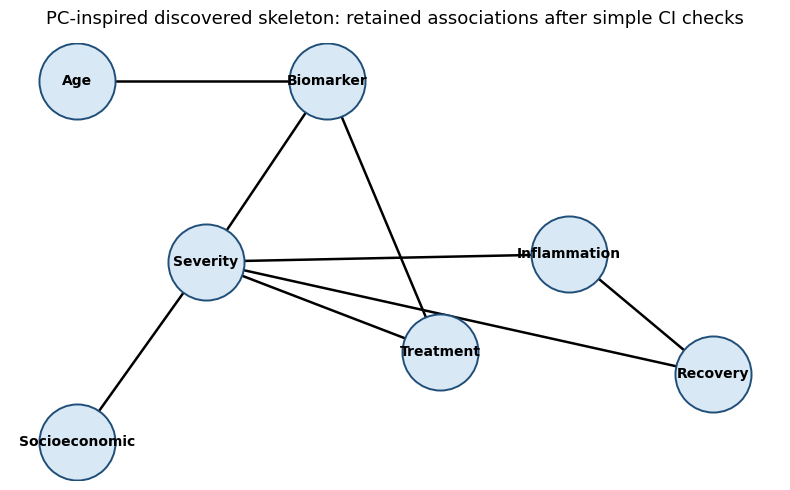

In [78]:
# Use positions from the assumed graph for visual comparability
pos_small = {k: pos[k] for k in variables_for_discovery}

G_skeleton = draw_undirected_graph(
    skeleton_edges,
    pos=pos_small,
    title="PC-inspired discovered skeleton: retained associations after simple CI checks",
    node_color=COLORS["light_blue"]
);

### Interpretation

The discovered skeleton is a **candidate graph structure**, not a confirmed causal graph.

The simplified learner follows a basic PC-style intuition:

- it keeps an edge when two variables remain associated after the simple independence checks used here;
- it removes an edge when the association is weak, or becomes weak after conditioning on another variable.

This reflects the same intuition as d-separation:

> If conditioning blocks the path between two variables, their association should become small.

However, this simplified learner has three important limitations:

- **It uses partial correlation**, so it mainly captures linear relationships and may miss nonlinear dependencies.
- **It conditions on only one variable at a time**, while a full PC algorithm checks larger conditioning sets.
- **It does not handle hidden confounders or fully orient edges**, so the result should not be treated as a confirmed causal DAG.

Therefore, the output should be interpreted as a **starting point for graph refinement**, not as the final causal structure.


</br></br>

---
### Example Continue: Orienting Edges with Temporal and Domain Knowledge

Causal discovery is often stronger when combined with expert constraints.

In the healthcare example, domain knowledge gives a rough ordering:

$$Age, Socioeconomic \rightarrow Severity$$
$$Biomarker \rightarrow Treatment \rightarrow Inflammation \rightarrow Recovery$$

This ordering does not prove the graph, but it prevents impossible directions such as `Recovery` causing baseline `Age`.

The next cell orients discovered skeleton edges according to this ordering.

Oriented edges: [('Age', 'Biomarker'), ('Socioeconomic', 'Severity'), ('Severity', 'Biomarker'), ('Severity', 'Treatment'), ('Severity', 'Inflammation'), ('Severity', 'Recovery'), ('Biomarker', 'Treatment'), ('Inflammation', 'Recovery')]
Unresolved same-level edges: []


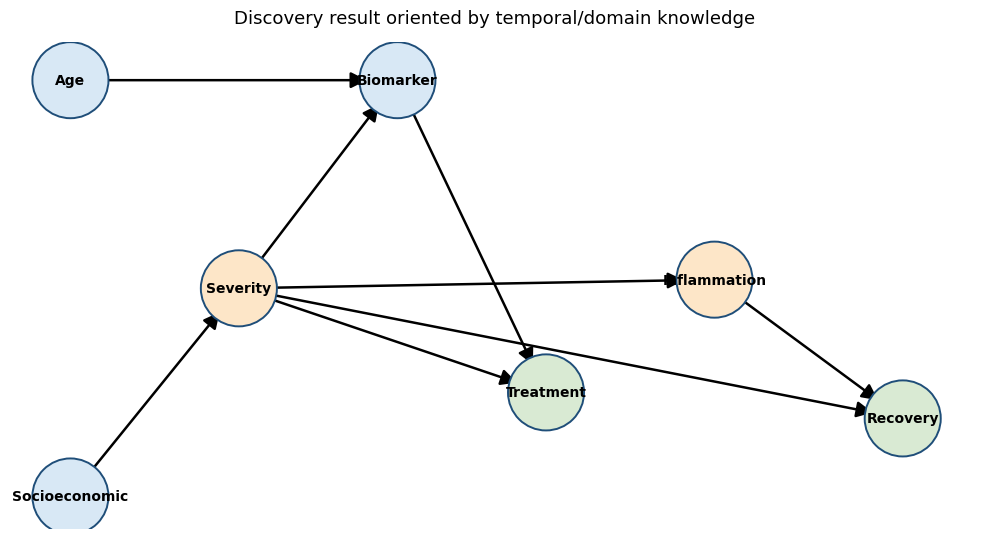

In [79]:
causal_order = {
    "Age": 0,
    "Socioeconomic": 0,
    "Severity": 1,
    "Biomarker": 2,
    "Treatment": 3,
    "Inflammation": 4,
    "Recovery": 5,
}

def orient_by_order(edges, order):
    oriented = []
    undirected = []
    for a, b in edges:
        if order[a] < order[b]:
            oriented.append((a, b))
        elif order[b] < order[a]:
            oriented.append((b, a))
        else:
            undirected.append((a, b))
    return oriented, undirected

oriented_edges, unresolved_edges = orient_by_order(skeleton_edges, causal_order)
print("Oriented edges:", oriented_edges)
print("Unresolved same-level edges:", unresolved_edges)

oriented_colors = {node: COLORS["light_blue"] for node in variables_for_discovery}
oriented_colors["Treatment"] = COLORS["light_green"]
oriented_colors["Recovery"] = COLORS["light_green"]
oriented_colors["Severity"] = COLORS["light_orange"]
oriented_colors["Inflammation"] = COLORS["light_orange"]

G_oriented = draw_dag(
    oriented_edges,
    pos=pos_small,
    title="Discovery result oriented by temporal/domain knowledge",
    node_colors=oriented_colors,
    figsize=(10, 5.5)
);

### Interpretation

The skeleton tells us which variables are connected, but not necessarily which way the arrows should point.

Here we use temporal and domain knowledge to orient edges. For example, baseline variables such as `Age` and `Socioeconomic` should not be caused by later variables such as `Recovery`.


</br></br>

---
### 9.3 Functional Causal Discovery: LiNGAM Intuition

The PC-style approach in the previous section is based mainly on **conditional independence**. It asks whether an association disappears after conditioning on other variables.

This is useful for removing edges and identifying some graph structures. But it often cannot fully determine causal direction from observational data.

For example, if two variables are associated, conditional independence alone may not tell us whether:

$$X \rightarrow Y$$

or

$$Y \rightarrow X$$

or whether both are influenced by another variable.

Functional causal discovery methods use a different philosophy.

Instead of asking only:

> *Which variables become independent after conditioning?*

they also ask:

> *Which direction gives a more plausible data-generating process?*

The idea is that causes generate effects through **structural equations**. A structural equation describes how one variable is produced from its direct causes plus some unexplained variation.

A general functional causal model can be written as:

$$X_i = f_i(Pa(X_i), e_i)$$

where:

- $X_i$ is the variable we want to explain,
- $Pa(X_i)$ are its causal parents, meaning its direct causes,
- $f_i$ is the function that maps the causes to $X_i$,
- $e_i$ is a noise term, meaning variation not explained by the parents.

In simple words:

> Each variable is generated by its causes plus some independent noise.

The key idea is:

> Causal direction may become identifiable if we make assumptions about the functional form and the noise.

---

### LiNGAM: Linear Non-Gaussian Acyclic Model

LiNGAM stands for **Linear Non-Gaussian Acyclic Model**.

It assumes that each variable is generated as a linear combination of its causal parents plus an independent non-Gaussian noise term:

$$X_i = \sum_{j \in Pa(i)} a_{ij}X_j + e_i$$

where:

- $Pa(i)$ is the set of causal parents of $X_i$,
- $a_{ij}$ is the causal coefficient from $X_j$ to $X_i$,
- $e_i$ is an independent noise term,
- the graph is acyclic, so there are no feedback loops,
- the noise terms are non-Gaussian and mutually independent.

Here, **linear** means that the causes are added together with coefficients. For example, one variable may increase or decrease another variable by a fixed amount.

**Non-Gaussian noise** means that the unexplained variation is not normally distributed. It may be skewed, heavy-tailed, or asymmetric.

This assumption is important.

In ordinary linear Gaussian models, the direction is usually not identifiable from observational data alone. A model such as:

$$X \rightarrow Y$$

can often fit the data about as well as:

$$Y \rightarrow X$$

LiNGAM tries to break this symmetry. It uses the idea that, in the correct causal direction, the residual should behave like an independent noise term. In the wrong direction, this independence is usually violated.

So the philosophy is:

> The correct causal direction should give a cleaner structural equation: cause plus independent noise.

Under its assumptions, LiNGAM can sometimes recover a causal ordering and orient edges.

---

### Why this matters

LiNGAM can be useful when:

- variables are continuous,
- relationships are approximately linear,
- hidden confounding is limited,
- noise terms are plausibly non-Gaussian,
- the goal is exploratory causal structure learning.

But LiNGAM should not be used as a black-box method.

Its output is meaningful only when its assumptions fit the scientific problem. Basic LiNGAM assumes linear relationships, independent non-Gaussian noise, an acyclic graph, and no important hidden confounders.

If these assumptions are not plausible, the estimated graph should be treated as an exploratory candidate graph, not as confirmed causal evidence.

### Visual intuition: why non-Gaussian noise matters in LiNGAM

<div style="color:#1f4e79; background-color:#eef5fb; border-left:4px solid #1f4e79; padding:10px 14px; margin:12px 0;">

<strong>Optional self-study.</strong><br>
If time is limited, we may skip this section in class. Please review it independently and run the code cells.

</div>

The purpose of this example is to show why LiNGAM requires non-Gaussian noise.

We simulate data from the true causal direction:

$$X \rightarrow Y$$

with the structural equation:

$$Y = aX + e$$

We compare two cases:

1. **Gaussian case:** both $X$ and the noise term $e$ are Gaussian.
2. **Non-Gaussian case:** both $X$ and $e$ are non-Gaussian.

In each case, we fit two regression models:

$$Y \sim X$$

and

$$X \sim Y$$

In ordinary linear regression, the residuals are uncorrelated with the predictor by construction. Therefore, ordinary residual correlation is not enough. To make the dependence more visible, we also examine whether the residual spread depends on the predictor using:

$$Corr(Predictor, Residual^2)$$

In the Gaussian case, both directions tend to look plausible. In the non-Gaussian case, the true direction should produce residuals that are more independent of the predictor, while the reverse direction may show dependence in the residual spread.

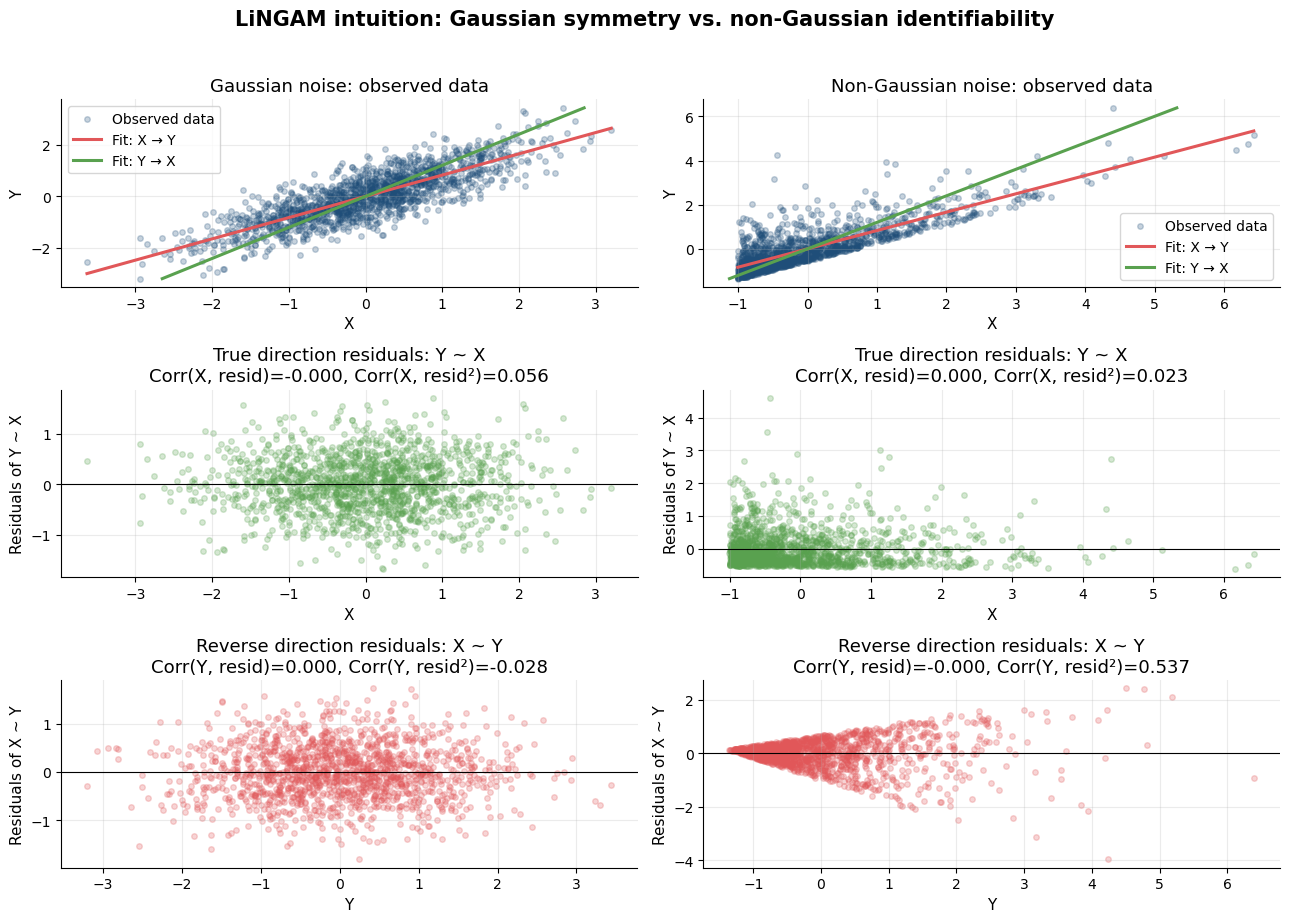

In [80]:
# ---------------------------------------------------------------------
# Simulation for LiNGAM intuition
# ---------------------------------------------------------------------

def simulate_linear_causal_data(n=1500, case="gaussian", seed=42):
    """
    Simulate data from the true causal model X -> Y.

    True structural equation:
        Y = aX + e

    In the Gaussian case, both X and e are Gaussian.
    In the non-Gaussian case, both X and e are centered exponential variables.
    """
    rng = np.random.default_rng(seed)
    a = 1.2

    if case == "gaussian":
        X = rng.normal(0, 1, n)
        e = rng.normal(0, 0.8, n)

    elif case == "non_gaussian":
        # Centered exponential variables are non-Gaussian and skewed.
        X = rng.exponential(1, n) - 1
        e = 0.8 * (rng.exponential(1, n) - 1)

    else:
        raise ValueError("case must be 'gaussian' or 'non_gaussian'.")

    Y = a * X + e

    # Standardize for clearer visualization
    X = (X - X.mean()) / X.std()
    Y = (Y - Y.mean()) / Y.std()

    return X, Y


def fit_residuals(predictor, target):
    """
    Fit target ~ predictor and return fitted values and residuals.
    """
    model = LinearRegression()
    model.fit(predictor.reshape(-1, 1), target)
    fitted = model.predict(predictor.reshape(-1, 1))
    residuals = target - fitted
    return fitted, residuals, model


def dependence_diagnostics(predictor, residuals):
    """
    Simple visual diagnostics for residual dependence.

    In OLS, Corr(predictor, residuals) is usually close to zero by construction.
    Therefore, we also check Corr(predictor, |residuals|) and Corr(predictor, residuals^2).
    These are simple indicators of dependence in spread or variance.
    """
    corr_resid = np.corrcoef(predictor, residuals)[0, 1]
    corr_abs = np.corrcoef(predictor, np.abs(residuals))[0, 1]
    corr_sq = np.corrcoef(predictor, residuals**2)[0, 1]

    return corr_resid, corr_abs, corr_sq


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

def plot_lingam_gaussian_vs_nongaussian(n=1500, seed=42):
    """
    Compare Gaussian and non-Gaussian cases for LiNGAM intuition.
    """
    cases = [
        ("gaussian", "Gaussian noise"),
        ("non_gaussian", "Non-Gaussian noise")
    ]

    fig, axes = plt.subplots(3, 2, figsize=(13, 9))

    for col, (case, title) in enumerate(cases):

        X, Y = simulate_linear_causal_data(n=n, case=case, seed=seed)

        # True direction: Y ~ X
        fitted_y_from_x, resid_y_from_x, model_yx = fit_residuals(X, Y)

        # Reverse direction: X ~ Y
        fitted_x_from_y, resid_x_from_y, model_xy = fit_residuals(Y, X)

        order_x = np.argsort(X)
        order_y = np.argsort(Y)

        # Reverse regression line is X_hat = bY + c.
        # To plot in X-Y coordinates, use x = X_hat and y = Y.
        x_line_reverse = fitted_x_from_y[order_y]
        y_line_reverse = Y[order_y]

        # Diagnostics
        corr_true, abs_true, sq_true = dependence_diagnostics(X, resid_y_from_x)
        corr_rev, abs_rev, sq_rev = dependence_diagnostics(Y, resid_x_from_y)

        # -------------------------------------------------------------
        # Row 1: observed data and regression lines
        # -------------------------------------------------------------
        ax = axes[0, col]
        ax.scatter(X, Y, alpha=0.25, s=16, color=COLORS["navy"], label="Observed data")

        ax.plot(
            X[order_x],
            fitted_y_from_x[order_x],
            color=COLORS["red"],
            linewidth=2.2,
            label="Fit: X → Y"
        )

        ax.plot(
            x_line_reverse,
            y_line_reverse,
            color=COLORS["green"],
            linewidth=2.2,
            label="Fit: Y → X"
        )

        ax.set_title(f"{title}: observed data")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.legend()
        clean_axis(ax)

        # -------------------------------------------------------------
        # Row 2: true direction residuals
        # -------------------------------------------------------------
        ax = axes[1, col]
        ax.scatter(X, resid_y_from_x, alpha=0.25, s=16, color=COLORS["green"])
        ax.axhline(0, color="black", linewidth=0.8)

        ax.set_title(
            "True direction residuals: Y ~ X\n"
            f"Corr(X, resid)={corr_true:.3f}, "
            f"Corr(X, resid²)={sq_true:.3f}"
        )
        ax.set_xlabel("X")
        ax.set_ylabel("Residuals of Y ~ X")
        clean_axis(ax)

        # -------------------------------------------------------------
        # Row 3: reverse direction residuals
        # -------------------------------------------------------------
        ax = axes[2, col]
        ax.scatter(Y, resid_x_from_y, alpha=0.25, s=16, color=COLORS["red"])
        ax.axhline(0, color="black", linewidth=0.8)

        ax.set_title(
            "Reverse direction residuals: X ~ Y\n"
            f"Corr(Y, resid)={corr_rev:.3f}, "
            f"Corr(Y, resid²)={sq_rev:.3f}"
        )
        ax.set_xlabel("Y")
        ax.set_ylabel("Residuals of X ~ Y")
        clean_axis(ax)

    fig.suptitle(
        "LiNGAM intuition: Gaussian symmetry vs. non-Gaussian identifiability",
        fontsize=15,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()
    plt.show()


plot_lingam_gaussian_vs_nongaussian(n=1500, seed=42)

### Interpretation

The figure compares two situations for the same true causal direction:

$$X \rightarrow Y$$

with the structural equation:

$$Y = aX + e$$

The left column shows the **Gaussian case**. Although the data were generated from $X \rightarrow Y$, both regression directions look plausible. The residual plots are fairly patternless in both directions. The residual-spread diagnostic is also small in both directions:

$$Corr(X, residual^2) = 0.056$$

$$Corr(Y, residual^2) = -0.028$$

This illustrates the symmetry problem in linear Gaussian models. With Gaussian noise, observational data alone often cannot distinguish whether $X$ causes $Y$ or $Y$ causes $X$.

</br>

The right column shows the **non-Gaussian case**. Here, the true direction $Y \sim X$ produces residuals that are much closer to independent of the predictor:

$$Corr(X, residual^2) = 0.023$$

However, the reverse direction $X \sim Y$ produces residuals whose spread clearly depends on the predictor:

$$Corr(Y, residual^2) = 0.537$$

The cone-shaped pattern in the lower-right panel shows that the residuals are not independent of $Y$ in the reverse direction. This makes the reverse model less compatible with the idea of an independent noise term.

This is the key intuition behind LiNGAM:

> In the correct causal direction, the residual should behave like an independent noise term. In the wrong direction, this independence is usually violated when the variables are generated by a linear non-Gaussian causal process.

Therefore, LiNGAM does not infer causality from correlation alone. It relies on additional assumptions: linear structural equations, acyclicity, independent noise terms, and non-Gaussianity. When these assumptions are plausible, causal direction can become identifiable from observational data.

</br>

### Example: LiNGAM and the Healthcare Use Case

We now apply the LiNGAM idea to the healthcare example. Since basic LiNGAM is designed for continuous variables with linear structural relationships, we focus only on the continuous part of the simulated dataset:

- `Age`
- `Socioeconomic`
- `Severity`
- `Biomarker`
- `Inflammation`

These variables are suitable for a simple LiNGAM demonstration because they are measured on continuous scales and can be interpreted as part of an underlying structural system.

We do **not** include binary variables such as `Treatment`, `Recovery`, and `SpecialistClinic` in this basic example. These variables require additional modeling choices, such as discrete causal discovery methods, generalized structural models, or mixed-data extensions.

The purpose of this example is not to claim that LiNGAM fully recovers the true healthcare graph. Instead, it shows how a functional causal discovery method can propose directed relationships among continuous variables when its assumptions are approximately plausible.

In [81]:
# ---------------------------------------------------------------------
# Functional causal discovery with LiNGAM
# ---------------------------------------------------------------------
# LiNGAM is optional. The notebook should still run if the package is not installed.

try:
    from lingam import DirectLiNGAM
    lingam_available = True
except Exception:
    lingam_available = False
    print("LiNGAM is not installed in this environment.")
    print("In Google Colab, you can install it with:")
    print("!pip install lingam")

if lingam_available:
    # LiNGAM is most appropriate here for continuous variables.
    cont_vars = ["Age", "Socioeconomic", "Severity", "Biomarker", "Inflammation"]

    # Standardize variables before fitting LiNGAM.
    X_lingam = StandardScaler().fit_transform(health[cont_vars])

    # Fit DirectLiNGAM.
    lingam_model = DirectLiNGAM()
    lingam_model.fit(X_lingam)

    # In lingam, adjacency_matrix_[i, j] means j -> i.
    adj = pd.DataFrame(
        lingam_model.adjacency_matrix_,
        index=cont_vars,
        columns=cont_vars
    )

    print("Estimated LiNGAM adjacency matrix")
    print("Rows are target variables; columns are source variables.")
    display(adj.round(2))

    # Convert adjacency matrix into graph edges.
    lingam_edges = []
    edge_labels = {}
    threshold = 0.10

    for target in cont_vars:
        for source in cont_vars:
            weight = adj.loc[target, source]

            if abs(weight) > threshold:
                lingam_edges.append((source, target))
                edge_labels[(source, target)] = f"{weight:.2f}"

    # Draw graph using comparable positions from the main DAG.
    G_lingam = nx.DiGraph()
    G_lingam.add_nodes_from(cont_vars)
    G_lingam.add_edges_from(lingam_edges)

    pos_lingam = {k: pos[k] for k in cont_vars}

    lingam_colors = {node: COLORS["light_blue"] for node in cont_vars}
    lingam_colors["Severity"] = COLORS["light_orange"]
    lingam_colors["Inflammation"] = COLORS["light_orange"]

    plt.figure(figsize=(9, 5))

    nx.draw(
        G_lingam,
        pos_lingam,
        with_labels=True,
        node_size=3000,
        node_color=[lingam_colors.get(node, COLORS["light_blue"]) for node in G_lingam.nodes()],
        edgecolors=COLORS["navy"],
        arrows=True,
        arrowsize=18,
        font_size=9,
        font_weight="bold",
        width=1.8,
    )

    nx.draw_networkx_edge_labels(
        G_lingam,
        pos_lingam,
        edge_labels=edge_labels,
        font_size=8
    )

    plt.title("LiNGAM candidate graph for continuous healthcare variables")
    plt.axis("off")
    plt.show()

LiNGAM is not installed in this environment.
In Google Colab, you can install it with:
!pip install lingam


### Interpretation

If LiNGAM is installed and the cell runs successfully, the output includes an estimated adjacency matrix and a candidate directed graph. Each nonzero entry represents a possible directed causal relationship.

In the adjacency matrix, rows are target variables and columns are source variables. Therefore, an entry in row `Severity` and column `Socioeconomic` represents a candidate edge:

$$Socioeconomic \rightarrow Severity$$

The graph visualizes the strongest estimated relationships after applying a threshold to the adjacency matrix.

This result should be interpreted as a **candidate causal structure**, not as a confirmed causal graph. LiNGAM is useful because it can sometimes orient edges from observational data, but this ability depends on strong assumptions.

For this example, LiNGAM is applied only to continuous variables. This is why `Treatment`, `Recovery`, and `SpecialistClinic` are excluded. Those variables are binary in this simulated dataset and are not ideal inputs for a basic linear LiNGAM demonstration.


> The main lesson is that functional causal discovery can add information about causal direction, but only under additional assumptions. It complements, rather than replaces, graph reasoning, temporal knowledge, and domain expertise.

</br></br>

---
## 10. Evaluation of Discovered Graphs

In real causal discovery, the true causal graph is usually unknown. This makes evaluation difficult.

Here, we simulated the healthcare data ourselves. So we know the graph that generated the data.

This gives us a useful teaching opportunity:

> We can compare the discovered graph with the known simulated graph.

In this section, we evaluate the simplified PC-inspired learner from Section 9.

We first evaluate the **skeleton**. The skeleton ignores arrow direction. It only asks whether two variables are connected.

For example, these two directed edges:

$$Severity \rightarrow Treatment$$

and

$$Treatment \rightarrow Severity$$

have the same skeleton connection:

$$Severity - Treatment$$

So the main question is:

> *Did the discovery method recover the correct variable connections?*

This is easier than evaluating the full directed graph. The reason is that causal directions are harder to identify from observational data.

### 10.1 What can be measured when the true graph is known?

When the true graph is known, as in a simulation, we can compare the discovered graph with the known graph.

At the skeleton level, each possible connection falls into one of three useful categories:

| Category | Meaning | Interpretation |
|---|---|---|
| **Correctly found** | The connection exists in the known graph and is also discovered | The method recovered a true connection |
| **Missed** | The connection exists in the known graph but is not discovered | The method failed to recover a true connection |
| **Extra** | The connection does not exist in the known graph but is discovered | The method added a false connection |

From these counts, we compute three simple metrics:

| Metric | Question it answers | Desired value |
|---|---|---|
| **Precision** | When the method finds a connection, how often is it correct? | Higher is better |
| **Recall** | How many true connections did the method recover? | Higher is better |
| **Skeleton SHD** | How many edge additions or removals are needed to match the known skeleton? | Lower is better |

The key distinction is:

> High precision means few **extra** edges.  
> High recall means few **missed** edges.

**Structural Hamming Distance (SHD)** measures how different two graphs are. At the skeleton level, it counts the number of edge additions or removals needed to make the discovered skeleton match the known skeleton.


### 10.2 Visual comparison: known skeleton vs. discovered skeleton

The next code cell compares two graphs:

1. the known skeleton from the simulated data-generating process;
2. the skeleton discovered by the simplified PC-inspired learner.

Both graphs use the same node positions, so the differences can be inspected visually.

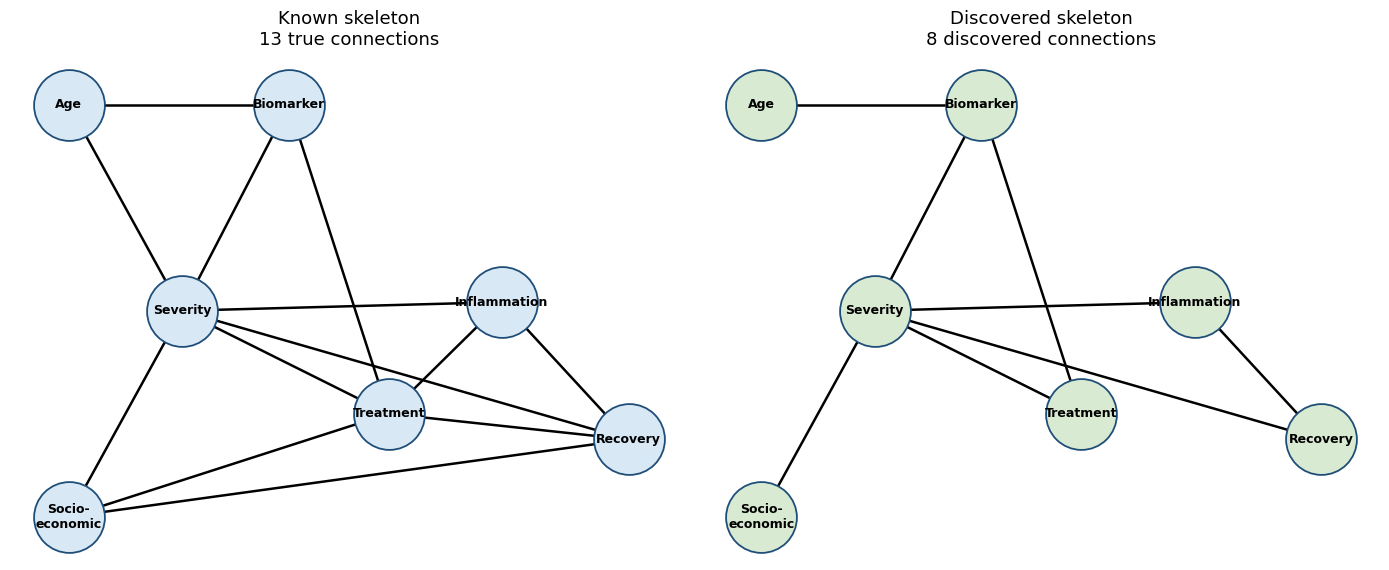

,Quantity,Value
0,Known true connections,13.000
1,Discovered connections,8.000
2,Correctly found connections,8.000
3,Missed connections,5.000
4,Extra connections,0.000
5,Precision,1.000
6,Recall,0.615
7,F1 score,0.762
8,Skeleton SHD,5.000


In [82]:
# ---------------------------------------------------------------------
# Evaluate discovered skeleton against the known simulated skeleton
# ---------------------------------------------------------------------

# This section assumes that the PC-inspired skeleton learner in Section 9
# has already been run and that skeleton_edges and variables_for_discovery exist.

def graph_connections(edge_list):
    """
    Convert directed or undirected edges into direction-free connections.

    For example:
        ("Severity", "Treatment")
    and
        ("Treatment", "Severity")

    are both treated as:
        ("Severity", "Treatment")
    """
    return {tuple(sorted(edge)) for edge in edge_list}


# Keep only the true edges among the variables used in the discovery example
true_small_edges = [
    edge for edge in true_edges
    if edge[0] in variables_for_discovery and edge[1] in variables_for_discovery
]

known_connections = graph_connections(true_small_edges)
discovered_connections = graph_connections(skeleton_edges)

# Compare sets of connections
correctly_found = known_connections.intersection(discovered_connections)
extra_found = discovered_connections.difference(known_connections)
missed_connections = known_connections.difference(discovered_connections)

# Counts
n_known = len(known_connections)
n_discovered = len(discovered_connections)
n_correct = len(correctly_found)
n_extra = len(extra_found)
n_missed = len(missed_connections)

# Metrics
precision = n_correct / n_discovered if n_discovered > 0 else 0
recall = n_correct / n_known if n_known > 0 else 0

f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0
)

# Skeleton SHD counts how many connections must be added or removed
# to make the discovered skeleton match the known skeleton.
skeleton_shd = n_missed + n_extra


# ---------------------------------------------------------------------
# Visual comparison: known skeleton vs. discovered skeleton
# ---------------------------------------------------------------------

def draw_skeleton_on_axis(
    ax,
    edges,
    pos,
    title,
    node_color=COLORS["light_blue"],
    edge_color="black",
    edge_width=1.8,
    labels=None,
):
    """
    Draw an undirected skeleton on a given matplotlib axis.
    """
    G = nx.Graph()
    G.add_nodes_from(variables_for_discovery)
    G.add_edges_from(edges)

    labels = labels or {node: node for node in G.nodes()}

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=2600,
        node_color=node_color,
        edgecolors=COLORS["navy"],
        linewidths=1.3,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        width=edge_width,
        edge_color=edge_color,
    )

    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        labels=labels,
        font_size=9,
        font_weight="bold",
    )

    ax.set_title(title, fontsize=13, pad=12)
    ax.axis("off")


# Use the same positions as the main DAG for visual comparability
pos_eval = {node: pos[node] for node in variables_for_discovery}

# Shorter labels for readability
eval_labels = {
    "Age": "Age",
    "Socioeconomic": "Socio-\neconomic",
    "Severity": "Severity",
    "Biomarker": "Biomarker",
    "Treatment": "Treatment",
    "Inflammation": "Inflammation",
    "Recovery": "Recovery",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

draw_skeleton_on_axis(
    axes[0],
    known_connections,
    pos_eval,
    title=f"Known skeleton\n{n_known} true connections",
    node_color=COLORS["light_blue"],
    edge_color="black",
    edge_width=1.8,
    labels=eval_labels,
)

draw_skeleton_on_axis(
    axes[1],
    discovered_connections,
    pos_eval,
    title=f"Discovered skeleton\n{n_discovered} discovered connections",
    node_color=COLORS["light_green"],
    edge_color="black",
    edge_width=1.8,
    labels=eval_labels,
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Compact metrics table
# ---------------------------------------------------------------------

metrics_table = pd.DataFrame({
    "Quantity": [
        "Known true connections",
        "Discovered connections",
        "Correctly found connections",
        "Missed connections",
        "Extra connections",
        "Precision",
        "Recall",
        "F1 score",
        "Skeleton SHD",
    ],
    "Value": [
        n_known,
        n_discovered,
        n_correct,
        n_missed,
        n_extra,
        round(precision, 3),
        round(recall, 3),
        round(f1, 3),
        skeleton_shd,
    ],
})

display(metrics_table)

### Interpretation

The left graph shows the known skeleton from the simulated data-generating process. It contains **13 true connections** among the variables used in the discovery example.

The right graph shows the skeleton recovered by the simplified PC-inspired learner. It contains **8 discovered connections**.

The metrics summarize the comparison:

- **8 connections were correctly found**.
- **5 true connections were missed**.
- **0 extra connections were added**.

This gives:

$$Precision = 1.000$$

$$Recall = 0.615$$

The high precision means that every discovered connection was present in the known graph. In this simulation, the method did not add false connections.

The lower recall means that the method recovered only part of the known graph. Some true connections were missed.

The **Skeleton SHD** is:

$$SHD = 5$$

This means that five edge changes would be needed to make the discovered skeleton match the known skeleton.

Overall, the simplified learner is **conservative** in this example. It avoids extra edges, but it misses some true relationships.

The main lesson is:

> Causal discovery can propose useful candidate graph structures, but it should not be treated as automatically recovering the true graph.

### 10.3 Which connections were found or missed?

<div style="color:#1f4e79; background-color:#eef5fb; border-left:4px solid #1f4e79; padding:10px 14px; margin:12px 0;">

<strong>Optional self-study.</strong><br>
If time is limited, we may skip this section in class. Please review it independently and run the code cells.

</div>

The previous table gives aggregate metrics. However, it does not show which specific connections were recovered or missed.

The next table gives an edge-level comparison. It shows whether each informative variable pair was:

- correctly found,
- missed,
- or extra.

In [83]:
# ---------------------------------------------------------------------
# 10.3 which connections were found or missed?
# ---------------------------------------------------------------------

# Create all possible variable pairs among the variables used for discovery
all_pairs = {
    tuple(sorted((a, b)))
    for i, a in enumerate(variables_for_discovery)
    for b in variables_for_discovery[i + 1:]
}

edge_comparison = []

for pair in sorted(all_pairs):

    in_known = pair in known_connections
    in_discovered = pair in discovered_connections

    if in_known and in_discovered:
        status = "Correctly found"
    elif in_known and not in_discovered:
        status = "Missed connection"
    elif not in_known and in_discovered:
        status = "Extra connection"
    else:
        status = "Correctly absent"

    edge_comparison.append({
        "Variable pair": " -- ".join(pair),
        "In known skeleton": in_known,
        "In discovered skeleton": in_discovered,
        "Result": status,
    })

edge_comparison_df = pd.DataFrame(edge_comparison)

# Keep only informative rows:
# correctly found, missed, and extra connections.
informative_results = edge_comparison_df[
    edge_comparison_df["Result"].isin([
        "Correctly found",
        "Missed connection",
        "Extra connection",
    ])
].copy()

# Sort results in a teaching-friendly order
status_order = {
    "Correctly found": 0,
    "Missed connection": 1,
    "Extra connection": 2,
}

informative_results["Order"] = informative_results["Result"].map(status_order)
informative_results = (
    informative_results
    .sort_values(["Order", "Variable pair"])
    .drop(columns="Order")
    .reset_index(drop=True)
)

display(informative_results)

,Variable pair,In known skeleton,In discovered skeleton,Result
0,Age -- Biomarker,True,True,Correctly found
1,Biomarker -- Severity,True,True,Correctly found
2,Biomarker -- Treatment,True,True,Correctly found
3,Inflammation -- Recovery,True,True,Correctly found
4,Inflammation -- Severity,True,True,Correctly found
5,Recovery -- Severity,True,True,Correctly found
6,Severity -- Socioeconomic,True,True,Correctly found
7,Severity -- Treatment,True,True,Correctly found
8,Age -- Severity,True,False,Missed connection
9,Inflammation -- Treatment,True,False,Missed connection


### Interpretation

This table shows which specific connections explain the summary metrics.

The **correctly found** rows are true relationships that the simplified learner recovered.

The **missed connection** rows are true relationships that the learner failed to recover. This can happen when:

- the relationship is weak,
- the relationship is partly explained by another variable,
- the method conditions on too few variables,
- the threshold is too strict,
- or the relationship is not well captured by linear partial correlation.

This is useful for teaching because it shows that even in simulation, where the true graph is known, a simple discovery method may recover only part of the structure.

### 10.4 Directional evaluation after orientation

<div style="color:#1f4e79; background-color:#eef5fb; border-left:4px solid #1f4e79; padding:10px 14px; margin:12px 0;">

<strong>Optional self-study.</strong><br>
If time is limited, we may skip this section in class. Please review it independently and run the code cells.

</div>

The previous evaluation ignored arrow directions. If we also have an oriented graph, we can compare directed edges.

This is stricter than skeleton evaluation because a discovered edge is correct only if both the connection and the arrow direction are correct.

However, in this chapter, directions were added using temporal and domain knowledge. Therefore, this section evaluates the combined workflow:

> simplified skeleton discovery + temporal/domain orientation

It does not evaluate a fully data-driven causal discovery method.

In [84]:
# ---------------------------------------------------------------------
# 10.4 directional evaluation after orientation
# ---------------------------------------------------------------------

# True directed edges among the variables used in the discovery example
true_directed_edges = set(true_small_edges)

# Directed edges obtained after applying temporal/domain orientation
discovered_directed_edges = set(oriented_edges)

# Compare directed edges
correct_directed = true_directed_edges.intersection(discovered_directed_edges)
missed_directed = true_directed_edges.difference(discovered_directed_edges)
extra_directed = discovered_directed_edges.difference(true_directed_edges)

# Counts
n_true_directed = len(true_directed_edges)
n_discovered_directed = len(discovered_directed_edges)
n_correct_directed = len(correct_directed)
n_missed_directed = len(missed_directed)
n_extra_directed = len(extra_directed)

# Metrics
directed_precision = (
    n_correct_directed / n_discovered_directed
    if n_discovered_directed > 0
    else 0
)

directed_recall = (
    n_correct_directed / n_true_directed
    if n_true_directed > 0
    else 0
)

directed_f1 = (
    2 * directed_precision * directed_recall / (directed_precision + directed_recall)
    if (directed_precision + directed_recall) > 0
    else 0
)

directed_results = pd.DataFrame({
    "Quantity": [
        "Known directed edges",
        "Discovered directed edges",
        "Correct directed edges",
        "Missed directed edges",
        "Extra directed edges",
        "Directed precision",
        "Directed recall",
        "Directed F1 score",
    ],
    "Value": [
        n_true_directed,
        n_discovered_directed,
        n_correct_directed,
        n_missed_directed,
        n_extra_directed,
        round(directed_precision, 3),
        round(directed_recall, 3),
        round(directed_f1, 3),
    ],
})

display(directed_results)

,Quantity,Value
0,Known directed edges,13.000
1,Discovered directed edges,8.000
2,Correct directed edges,8.000
3,Missed directed edges,5.000
4,Extra directed edges,0.000
5,Directed precision,1.000
6,Directed recall,0.615
7,Directed F1 score,0.762


In [85]:
# ---------------------------------------------------------------------
# Detailed directed-edge comparison
# ---------------------------------------------------------------------

directed_edge_rows = []

all_directed_edges_to_show = (
    true_directed_edges
    .union(discovered_directed_edges)
)

for edge in sorted(all_directed_edges_to_show):

    in_true = edge in true_directed_edges
    in_discovered = edge in discovered_directed_edges

    if in_true and in_discovered:
        status = "Correct directed edge"
    elif in_true and not in_discovered:
        status = "Missed directed edge"
    elif not in_true and in_discovered:
        status = "Extra directed edge"

    directed_edge_rows.append({
        "Directed edge": f"{edge[0]} → {edge[1]}",
        "In known graph": in_true,
        "In discovered graph": in_discovered,
        "Result": status,
    })

directed_edge_comparison = pd.DataFrame(directed_edge_rows)

directed_status_order = {
    "Correct directed edge": 0,
    "Missed directed edge": 1,
    "Extra directed edge": 2,
}

directed_edge_comparison["Order"] = directed_edge_comparison["Result"].map(directed_status_order)
directed_edge_comparison = (
    directed_edge_comparison
    .sort_values(["Order", "Directed edge"])
    .drop(columns="Order")
    .reset_index(drop=True)
)

display(directed_edge_comparison)

,Directed edge,In known graph,In discovered graph,Result
0,Age → Biomarker,True,True,Correct directed edge
1,Biomarker → Treatment,True,True,Correct directed edge
2,Inflammation → Recovery,True,True,Correct directed edge
3,Severity → Biomarker,True,True,Correct directed edge
4,Severity → Inflammation,True,True,Correct directed edge
5,Severity → Recovery,True,True,Correct directed edge
6,Severity → Treatment,True,True,Correct directed edge
7,Socioeconomic → Severity,True,True,Correct directed edge
8,Age → Severity,True,False,Missed directed edge
9,Socioeconomic → Recovery,True,False,Missed directed edge


### Interpretation

Directional evaluation is stricter than skeleton evaluation.

A directed edge is counted as correct only when both the connection and the arrow direction match the known simulated graph.

In this example, the directed metrics are the same as the skeleton metrics because all retained skeleton edges were oriented consistently with the known simulated graph.

However, this result should be interpreted carefully. The directions were not learned purely from data. They were added using temporal and domain knowledge.

The main lesson is:

> In applied causal discovery, graph learning is often a hybrid process: data can suggest candidate connections, while domain knowledge and time ordering help orient and refine them.

---
## 11. Chapter Summary

This chapter introduced causal graphs and causal discovery as practical tools for causal intelligence.

Key points from the chapter:

- DAGs represent assumptions about how variables may influence each other.
- Forks, chains, and colliders explain why conditioning can reduce bias, change the causal question, or create bias.
- d-separation connects graph structure to conditional independence.
- The Causal Markov Condition and Faithfulness explain how graphs and data patterns can be connected, but only under assumptions.
- Backdoor paths explain why naive observational comparisons may be biased.
- Backdoor adjustment can be implemented in Python using model-based standardization.
- Causal discovery methods use statistical patterns to propose candidate graph structures.
- PC-style methods rely on conditional independence, while LiNGAM relies on functional assumptions such as linearity and non-Gaussian noise.
- Discovery results should be interpreted as candidate graphs, not causal truth.
- In simulation, we can compare discovered and known graphs; in real applications, the true graph is usually unknown.

The practical message is:

> Causal intelligence starts by making assumptions explicit, then uses data, domain knowledge, and careful reasoning to test, refine, and act on those assumptions.

## 12. References and Further Reading

### Foundational causal graphs and causal inference

- Pearl, J. (2009). [*Causality: Models, Reasoning, and Inference*](https://www.cambridge.org/core/books/causality/B0046844FAE10CBF274D4ACBDAEB5F5B). Cambridge University Press.  
  A foundational reference for graphical causal models, do-calculus, interventions, and causal reasoning.

- Pearl, J., Glymour, M., and Jewell, N. P. (2016). [*Causal Inference in Statistics: A Primer*](https://www.wiley.com/en-us/Causal+Inference+in+Statistics%3A+A+Primer-p-9781119186847). Wiley.  
  A concise and accessible introduction to causal diagrams, confounding, adjustment, and causal effects.

- Hernán, M. A., and Robins, J. M. (2020). [*Causal Inference: What If*](https://miguelhernan.org/whatifbook). Chapman & Hall/CRC.  
  A practical reference for causal questions, interventions, observational studies, and adjustment.

- Peters, J., Janzing, D., and Schölkopf, B. (2017). [*Elements of Causal Inference: Foundations and Learning Algorithms*](https://mitpress.mit.edu/9780262037310/elements-of-causal-inference/). MIT Press.  
  A compact reference connecting causal graphs, structural causal models, and causal discovery.

- Spirtes, P., Glymour, C., and Scheines, R. (2000). [*Causation, Prediction, and Search*](https://mitpress.mit.edu/9780262194402/causation-prediction-and-search/). MIT Press.  
  A classic reference for constraint-based causal discovery, including the PC algorithm and graphical causal modeling.

- Chickering, D. M. (2002). [“Optimal Structure Identification with Greedy Search”](https://www.jmlr.org/papers/v3/chickering02b.html). *Journal of Machine Learning Research*.  
  A foundational paper for score-based structure learning and Greedy Equivalence Search.

### Functional causal discovery and nonlinear discovery

- Shimizu, S., Hoyer, P. O., Hyvärinen, A., and Kerminen, A. (2006). [“A Linear Non-Gaussian Acyclic Model for Causal Discovery”](https://www.jmlr.org/papers/v7/shimizu06a.html). *Journal of Machine Learning Research*.  
  The original LiNGAM paper, explaining how non-Gaussian noise can help identify causal direction in linear acyclic models.

- Hoyer, P. O., Janzing, D., Mooij, J. M., Peters, J., and Schölkopf, B. (2008). [“Nonlinear Causal Discovery with Additive Noise Models”](https://proceedings.neurips.cc/paper_files/paper/2008/hash/f7664060cc52bc6f3d620bcedc94a4b6-Abstract.html). *NeurIPS*.  
  A key reference for additive noise models and functional causal discovery beyond linear models.

- Zhang, K., and Hyvärinen, A. (2009). [“On the Identifiability of the Post-Nonlinear Causal Model”](https://arxiv.org/abs/1205.2599).  
  A reference for post-nonlinear causal models and identifiability under functional assumptions.

### Machine-learning-based causal discovery

- Zheng, X., Aragam, B., Ravikumar, P. K., and Xing, E. P. (2018). [“DAGs with NO TEARS: Continuous Optimization for Structure Learning”](https://arxiv.org/abs/1803.01422). *NeurIPS*.  
  Introduces NOTEARS, a continuous optimization approach to learning DAGs.

- Yu, Y., Chen, J., Gao, T., and Yu, M. (2019). [“DAG-GNN: DAG Structure Learning with Graph Neural Networks”](https://arxiv.org/abs/1904.10098).  
  An example of neural-network-based causal structure learning.

- Runge, J., Nowack, P., Kretschmer, M., Flaxman, S., and Sejdinovic, D. (2019). [“Detecting and Quantifying Causal Associations in Large Nonlinear Time Series Datasets”](https://www.science.org/doi/10.1126/sciadv.aau4996). *Science Advances*.  
  Introduces a scalable framework for causal discovery in nonlinear time-series settings, including ideas used in PCMCI-style workflows.

### Python tools and documentation

- [NetworkX documentation](https://networkx.org/documentation/stable/)  
  Used in this chapter for drawing and inspecting graphs.

- [scikit-learn documentation](https://scikit-learn.org/stable/)  
  Used in this chapter for regression, logistic regression, standardization, and simple model-based adjustment.

- [LiNGAM Python package](https://lingam.readthedocs.io/en/latest/)  
  Optional package for running LiNGAM-based causal discovery examples.

- [causal-learn documentation](https://causal-learn.readthedocs.io/en/latest/)  
  Python package for causal discovery methods including PC, FCI, GES, and related algorithms.

- [Tigramite documentation](https://jakobrunge.github.io/tigramite/)  
  Python package for causal discovery in time-series data.